# Two-Stage Experiment — Relative-Weight (lambda) Sweep EDA

CSVs: `experiment_rel_<size>.csv` (paper, small, medium, xlarge, ...).

Each instance is solved across a **dimensionless relative weight**
`lambda_rel`, where the absolute Stage-1 exposure penalty is
`weight = lambda * normalizer` and `normalizer` is the mean dispatch cost
per trip of that instance's cost-optimal (lambda=0) plan. So `lambda = 1`
means "pay one average dispatch to remove one exposure" on every instance
alike, which makes the curves comparable across size classes and seeds.

Sweep: `lambda in {0, 0.1, 0.25, 0.5, 1, 2, 4, 8}`.
Stage-2 packing configs: `baseline / mixed / even / full`.

Stage-1 metrics (`r_tr`, `exposure_count`, `s1_dispatch_cost`) depend only
on (instance, lambda); the four configs share one Stage-1 solve, so those
plots dedupe to one row per (instance, lambda).


In [2]:
from __future__ import annotations

import glob
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
    "figure.figsize": (10, 5),
})

# Load every relative-sweep CSV in this folder
CSV_GLOB = "experiment_rel_*.csv"

SIZE_ORDER   = ["paper", "small", "medium", "large", "xlarge", "industrylite"]
CONFIG_ORDER = ["baseline", "mixed", "even", "full"]
CONFIG_COLOR = {"baseline": "#1f77b4", "mixed": "#ff7f0e",
                "even":     "#ffa94d", "full":  "#9467bd"}
SIZE_COLOR   = {"paper": "#2ca02c", "small": "#1f77b4", "medium": "#ff7f0e",
                "large": "#d62728", "xlarge": "#9467bd", "industrylite": "#8c564b"}
SIZE_MARKER  = {"paper": "o", "small": "s", "medium": "^",
                "large": "D", "xlarge": "P", "industrylite": "X"}
ALPHAS = [0.2, 0.4, 0.6, 0.8]


In [3]:
frames = []
for f in sorted(glob.glob(CSV_GLOB)):
    d = pd.read_csv(f)
    d["__file"] = os.path.basename(f)
    frames.append(d)
if not frames:
    raise SystemExit(f"No CSVs matched {CSV_GLOB} in {os.getcwd()}")
df = pd.concat(frames, ignore_index=True)
df = df[df["status"] == "OK"].copy()

# Categorical ordering
present_sizes = [s for s in SIZE_ORDER if s in set(df["instance_size"])]
df["instance_size"] = pd.Categorical(df["instance_size"], categories=SIZE_ORDER, ordered=True)
df["s2_config"]     = pd.Categorical(df["s2_config"],     categories=CONFIG_ORDER, ordered=True)
df["lambda_rel"]    = df["lambda_rel"].astype(float)

# Derived columns
df["total_time"] = df["s1_time"] + df["s2_time"]
df["cost_saving_pct"] = np.where(
    df["s1_dispatch_cost"] > 0,
    df["cost_saving"] / df["s1_dispatch_cost"] * 100,
    np.nan,
)

# Stage-1 cost premium vs each instance's own lambda=0 plan (%).
base_s1 = (df[df["lambda_rel"] == 0]
           .drop_duplicates("instance_name")
           .set_index("instance_name")["s1_dispatch_cost"])
df["s1_cost_premium_pct"] = (
    (df["s1_dispatch_cost"] - df["instance_name"].map(base_s1))
    / df["instance_name"].map(base_s1) * 100
)

LAMBDAS = sorted(df["lambda_rel"].unique())
print(f"{len(df)} rows | sizes={present_sizes} | "
      f"lambdas={LAMBDAS} | seeds={sorted(df['seed'].unique())}")
df.head(3)


564 rows | sizes=['paper', 'small', 'medium', 'xlarge', 'industrylite'] | lambdas=[np.float64(0.0), np.float64(0.1), np.float64(0.25), np.float64(0.5), np.float64(1.0), np.float64(2.0), np.float64(4.0), np.float64(8.0)] | seeds=[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


,instance_name,instance_type,instance_size,seed,n_locations,n_parts,n_routes,n_transports,density,capacity_tightness,...,first_r_heaviest_single_0.8,first_r_heaviest_global_0.2,first_r_heaviest_global_0.4,first_r_heaviest_global_0.6,first_r_heaviest_global_0.8,status,__file,total_time,cost_saving_pct,s1_cost_premium_pct
0,layered_industrylite_seed2,layered,industrylite,2,20,10,524,4,0.345,9.956,...,NaN,NaN,NaN,NaN,NaN,OK,experiment_rel_industrylite.csv,648.097,23.753827,0.0
1,layered_industrylite_seed2,layered,industrylite,2,20,10,524,4,0.345,9.956,...,NaN,NaN,NaN,NaN,NaN,OK,experiment_rel_industrylite.csv,633.966,23.753827,0.0
2,layered_industrylite_seed2,layered,industrylite,2,20,10,524,4,0.345,9.956,...,NaN,NaN,NaN,NaN,NaN,OK,experiment_rel_industrylite.csv,604.159,12.627183,0.0


## 0. Grid coverage & data health

Confirm the sweep is balanced and note where Stage 1 / Stage 2 were not
**proven optimal** — on the larger classes the reported costs are anytime
best solutions, not certified optima, and that caveat carries through every
plot below.

In [4]:
grid = (df.groupby(["instance_size", "lambda_rel", "s2_config"], observed=True)
          .size().rename("n").reset_index()
          .pivot_table(index=["instance_size", "lambda_rel"],
                       columns="s2_config", values="n", fill_value=0,
                       observed=True))
grid


s2_config                 baseline  mixed  even  full
instance_size lambda_rel                             
paper         0.00             1.0    1.0   1.0   1.0
              0.10             1.0    1.0   1.0   1.0
              0.25             1.0    1.0   1.0   1.0
              0.50             1.0    1.0   1.0   1.0
              1.00             1.0    1.0   1.0   1.0
              2.00             1.0    1.0   1.0   1.0
              4.00             1.0    1.0   1.0   1.0
              8.00             1.0    1.0   1.0   1.0
small         0.00             5.0    5.0   5.0   5.0
              0.10             5.0    5.0   5.0   5.0
              0.25             5.0    5.0   5.0   5.0
              0.50             5.0    5.0   5.0   5.0
              1.00             5.0    5.0   5.0   5.0
              2.00             5.0    5.0   5.0   5.0
              4.00             5.0    5.0   5.0   5.0
              8.00             5.0    5.0   5.0   5.0
medium        0.00             5.0    5.0   5.0   5.0
              0.10             5.0    5.0   5.0   5.0
              0.25             5.0    5.0   5.0   5.0
              0.50             5.0    5.0   5.0   5.0
              1.00             5.0    5.0   5.0   5.0
              2.00             5.0    5.0   5.0   5.0
              4.00             5.0    5.0   5.0   5.0
              8.00             5.0    5.0   5.0   5.0
xlarge        0.00             5.0    5.0   5.0   5.0
              0.10             5.0    5.0   5.0   5.0
              0.25             5.0    5.0   5.0   5.0
              0.50             5.0    5.0   5.0   5.0
              1.00             5.0    5.0   5.0   5.0
              2.00             4.0    4.0   4.0   4.0
              4.00             4.0    4.0   4.0   4.0
              8.00             4.0    4.0   4.0   4.0
industrylite  0.00             4.0    4.0   4.0   4.0
              0.50             4.0    4.0   4.0   4.0
              1.00             4.0    4.0   4.0   4.0
              4.00             4.0    4.0   4.0   4.0

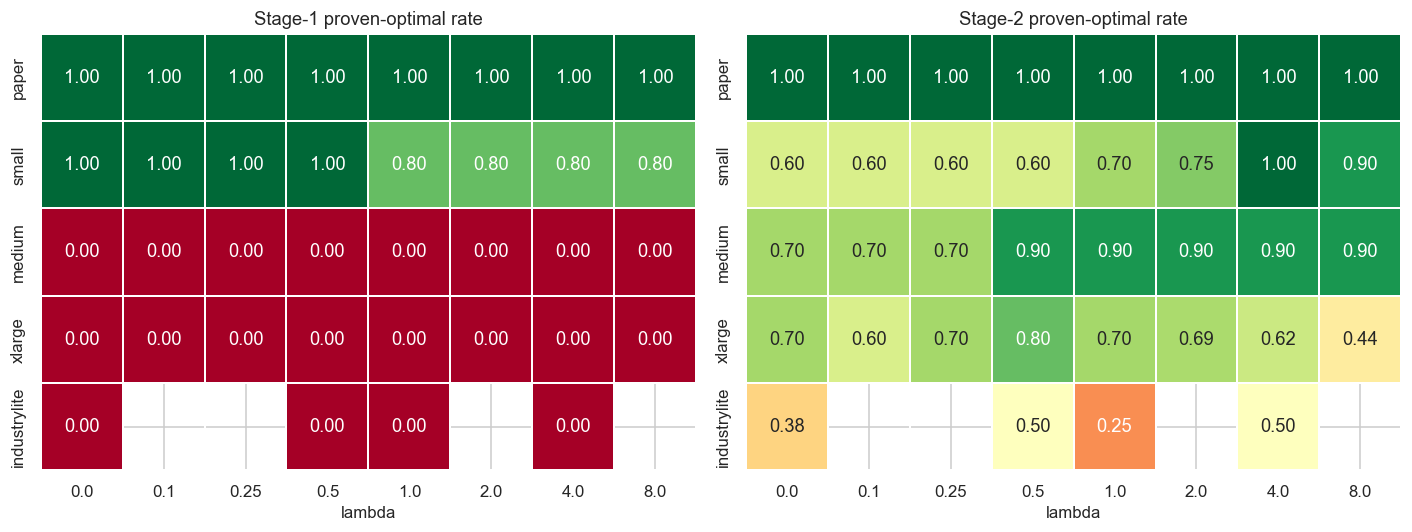

In [5]:
def plot_optimality(df):
    # Stage-1 status is config-independent; dedupe to (instance, lambda).
    s1 = df.drop_duplicates(["instance_name", "lambda_rel"])
    fig, axes = plt.subplots(1, 2, figsize=(13, 0.5 * len(present_sizes) + 2.5))
    for ax, (src, col, title) in zip(
        axes,
        [(s1, "s1_optimal", "Stage-1 proven-optimal rate"),
         (df, "s2_optimal", "Stage-2 proven-optimal rate")],
    ):
        mat = (src.assign(opt=src[col].astype(float))
                  .pivot_table(index="instance_size", columns="lambda_rel",
                               values="opt", aggfunc="mean", observed=True)
                  .reindex(present_sizes))
        sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
                    ax=ax, cbar=False, linewidths=0.3, linecolor="white")
        ax.set_title(title)
        ax.set_xlabel("lambda"); ax.set_ylabel("")
    fig.tight_layout(); plt.show()

plot_optimality(df)


### Normalizer & lambda -> weight mapping

The normalizer (mean trip cost at lambda=0) is what makes lambda comparable
across instances. This table shows, per instance, the normalizer and the
absolute integer weight each lambda resolved to.

In [6]:
norm = (df.drop_duplicates("instance_name")
          .set_index("instance_name")[["instance_size", "weight_normalizer"]]
          .sort_values(["instance_size", "instance_name"]))
weight_map = (df.drop_duplicates(["instance_name", "lambda_rel"])
                .pivot_table(index="instance_name", columns="lambda_rel",
                             values="weight", aggfunc="first", observed=True))
display(norm)
weight_map


,instance_size,weight_normalizer
instance_name,,
layered_paper,paper,157.1818
layered_small_seed1,small,108.1622
layered_small_seed2,small,77.5909
layered_small_seed3,small,122.4681
layered_small_seed4,small,111.2941
layered_small_seed5,small,194.0909
layered_medium_seed1,medium,162.7273
layered_medium_seed2,medium,145.0000
layered_medium_seed3,medium,230.1690


lambda_rel,0.00,0.10,0.25,0.50,1.00,2.00,4.00,8.00
instance_name,,,,,,,,
layered_industrylite_seed2,0.0,NaN,NaN,146.0,291.0,NaN,1165.0,NaN
layered_industrylite_seed3,0.0,NaN,NaN,88.0,176.0,NaN,705.0,NaN
layered_industrylite_seed4,0.0,NaN,NaN,139.0,278.0,NaN,1112.0,NaN
layered_industrylite_seed5,0.0,NaN,NaN,99.0,197.0,NaN,790.0,NaN
layered_medium_seed1,0.0,16.0,41.0,81.0,163.0,325.0,651.0,1302.0
layered_medium_seed2,0.0,14.0,36.0,72.0,145.0,290.0,580.0,1160.0
layered_medium_seed3,0.0,23.0,58.0,115.0,230.0,460.0,921.0,1841.0
layered_medium_seed4,0.0,10.0,26.0,52.0,103.0,206.0,412.0,824.0
layered_medium_seed5,0.0,13.0,32.0,65.0,129.0,258.0,517.0,1033.0


## 1. Stage-1 trade-off across lambda (headline)

These are the figures the relative sweep exists to produce: how the
cost-optimal routing gives way to a resilient one as the price lambda rises.


### 1.1 The trade-off staircase — dispatch cost vs exposures vs lambda

One panel per size. Left axis: mean Stage-1 dispatch cost. Right axis: mean
exposure count. As lambda rises the solver pays more dispatch to drive
exposures down — the staircase the absolute-weight sweep jumped over.

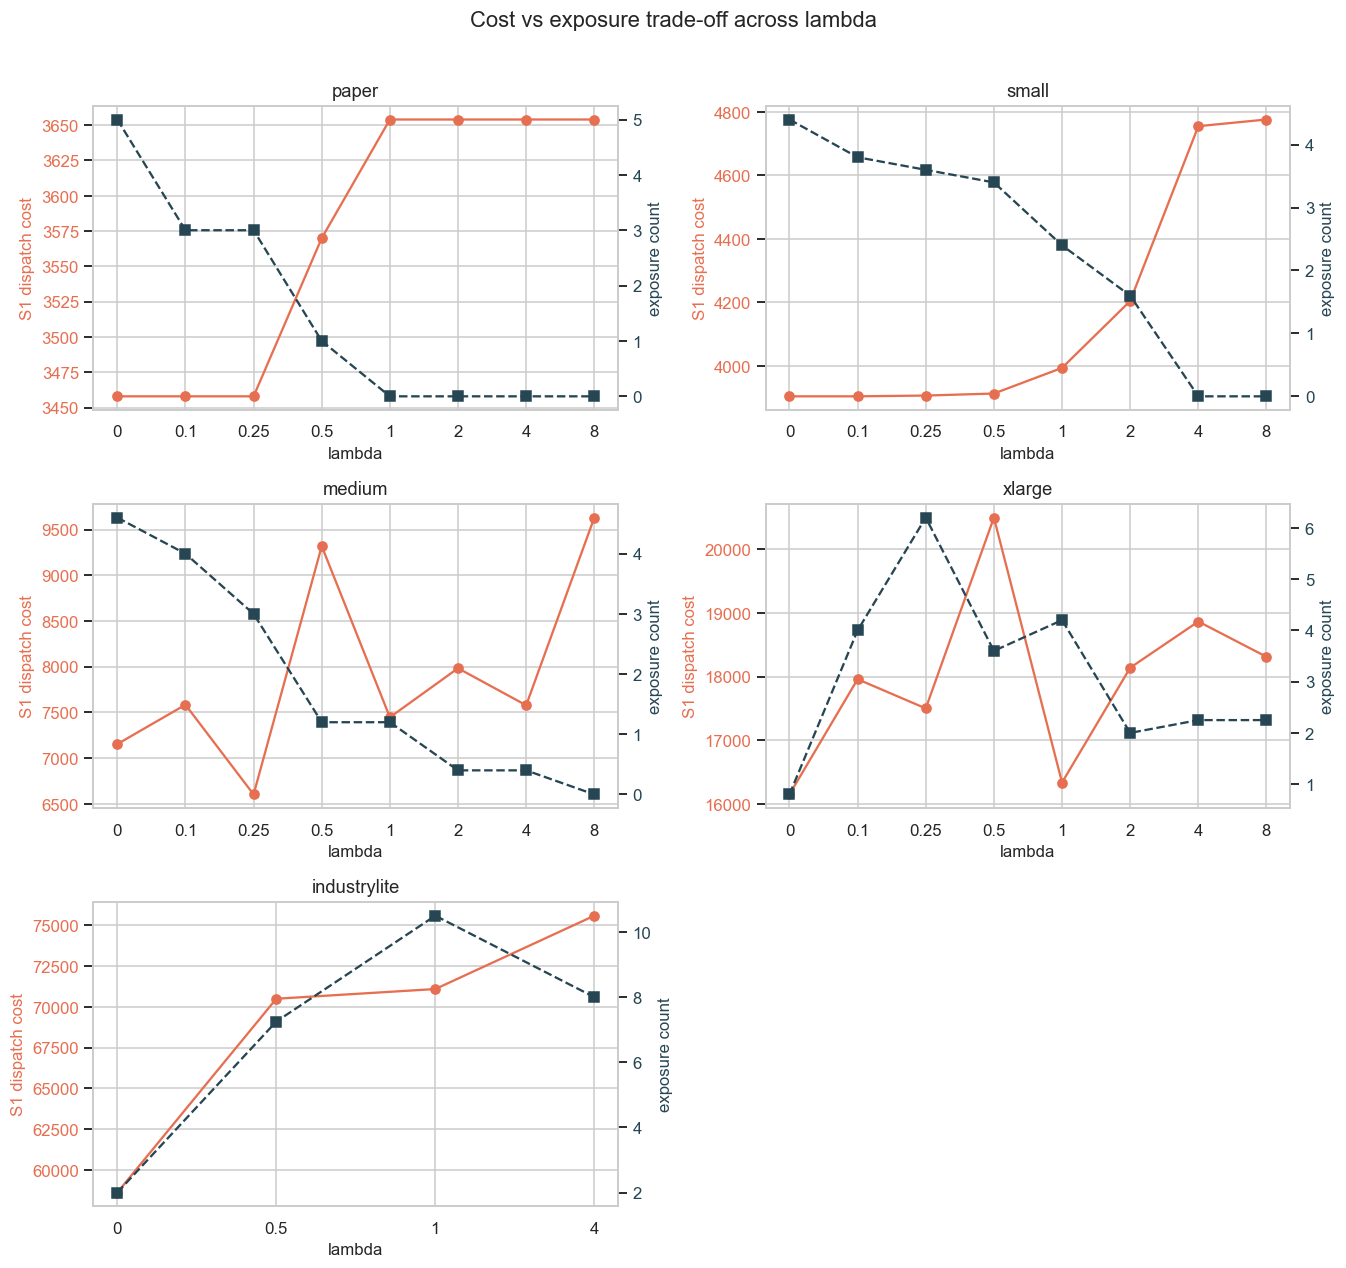

In [7]:
def plot_staircase(df):
    s1 = df.drop_duplicates(["instance_name", "lambda_rel"])
    n = len(present_sizes)
    cols = min(2, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6.2 * cols, 3.8 * rows),
                             squeeze=False)
    for ax, size in zip(axes.flat, present_sizes):
        s = s1[s1["instance_size"] == size]
        g = s.groupby("lambda_rel").agg(cost=("s1_dispatch_cost", "mean"),
                                        exp=("exposure_count", "mean")).reset_index()
        x = np.arange(len(g))
        ax.plot(x, g["cost"], "o-", color="#e76f51", label="dispatch cost")
        ax.set_ylabel("S1 dispatch cost", color="#e76f51")
        ax.tick_params(axis="y", labelcolor="#e76f51")
        ax.set_xticks(x); ax.set_xticklabels([f"{v:g}" for v in g["lambda_rel"]])
        ax.set_xlabel("lambda")
        ax.set_title(size)
        ax2 = ax.twinx()
        ax2.plot(x, g["exp"], "s--", color="#264653", label="exposures")
        ax2.set_ylabel("exposure count", color="#264653")
        ax2.tick_params(axis="y", labelcolor="#264653")
        ax2.grid(False)
    for ax in axes.flat[n:]:
        ax.set_visible(False)
    fig.suptitle("Cost vs exposure trade-off across lambda", y=1.01)
    fig.tight_layout(); plt.show()

plot_staircase(df)


### 1.2 R_TR vs lambda

Arc-level resilience as a function of lambda, one line per size (mean over
seeds, band = +/-1 sd). Note R_TR need not be monotone: the exposure
heuristic targets flow concentration, not worst-arc coverage, so
intermediate lambda can dip before exposures vanish.

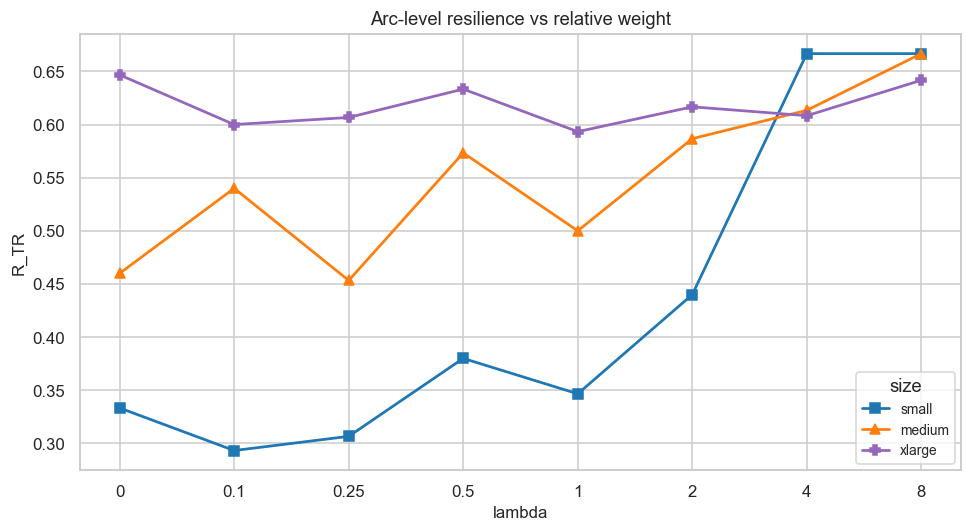

In [8]:
def plot_rtr_vs_lambda(df):
    s1 = df.drop_duplicates(["instance_name", "lambda_rel"])
    sizes = ['small', 'medium', 'xlarge']
    s1 = s1[s1["instance_size"].isin(sizes)]
    present_sizes = [s for s in sizes if s in set(df["instance_size"])]
    fig, ax = plt.subplots(figsize=(9, 5))
    for size in present_sizes:
        s = s1[s1["instance_size"] == size]
        g = s.groupby("lambda_rel")["r_tr"].agg(["mean", "std"]).reset_index()
        x = np.arange(len(g))
        ax.plot(x, g["mean"], marker=SIZE_MARKER[size], color=SIZE_COLOR[size],
                label=size, linewidth=1.8)
        # sd = g["std"].fillna(0)
        # ax.fill_between(x, g["mean"] - sd, g["mean"] + sd,
        #                 color=SIZE_COLOR[size], alpha=0.12)
    ax.set_xticks(range(len(LAMBDAS)))
    ax.set_xticklabels([f"{v:g}" for v in LAMBDAS])
    ax.set_xlabel("lambda"); ax.set_ylabel("R_TR")
    ax.set_title("Arc-level resilience vs relative weight")
    ax.legend(title="size")
    fig.tight_layout(); plt.show()

plot_rtr_vs_lambda(df)


### 1.3 Resilience premium — Stage-1 cost increase vs lambda

The dispatch-cost overhead each instance pays relative to its own lambda=0
plan. The value at the largest lambda is the price of the (near-)fully
de-exposed routing.

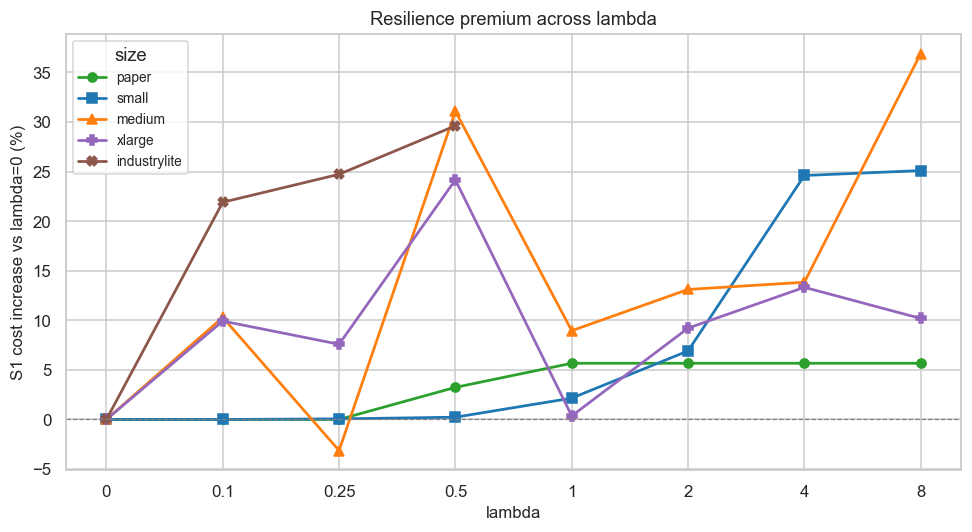

In [9]:
def plot_premium(df):
    s1 = df.drop_duplicates(["instance_name", "lambda_rel"])
    fig, ax = plt.subplots(figsize=(9, 5))
    for size in present_sizes:
        s = s1[s1["instance_size"] == size]
        g = s.groupby("lambda_rel")["s1_cost_premium_pct"].mean().reset_index()
        x = np.arange(len(g))
        ax.plot(x, g["s1_cost_premium_pct"], marker=SIZE_MARKER[size],
                color=SIZE_COLOR[size], label=size, linewidth=1.8)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xticks(range(len(LAMBDAS)))
    ax.set_xticklabels([f"{v:g}" for v in LAMBDAS])
    ax.set_xlabel("lambda"); ax.set_ylabel("S1 cost increase vs lambda=0 (%)")
    ax.set_title("Resilience premium across lambda")
    ax.legend(title="size")
    fig.tight_layout(); plt.show()

plot_premium(df)


### 1.4 Critical lambda — where the routing turns resilient

Per instance: the smallest lambda at which exposures first reach their
minimum (often zero). Reported as the resolved absolute weight too. NaN =
the minimum was already at lambda=0, or never improved within the sweep.

,instance,size,exp_at_0,exp_min,critical_lambda,weight_at_crit
0,layered_industrylite_seed2,industrylite,0,0,NaN,0
1,layered_industrylite_seed3,industrylite,0,0,NaN,0
2,layered_industrylite_seed4,industrylite,6,6,NaN,0
3,layered_industrylite_seed5,industrylite,2,2,NaN,0
4,layered_medium_seed1,medium,6,0,8.00,1302
5,layered_medium_seed2,medium,2,0,0.25,36
6,layered_medium_seed3,medium,10,0,2.00,460
7,layered_medium_seed4,medium,5,0,2.00,206
8,layered_medium_seed5,medium,0,0,NaN,0
9,layered_paper,paper,5,0,1.00,157


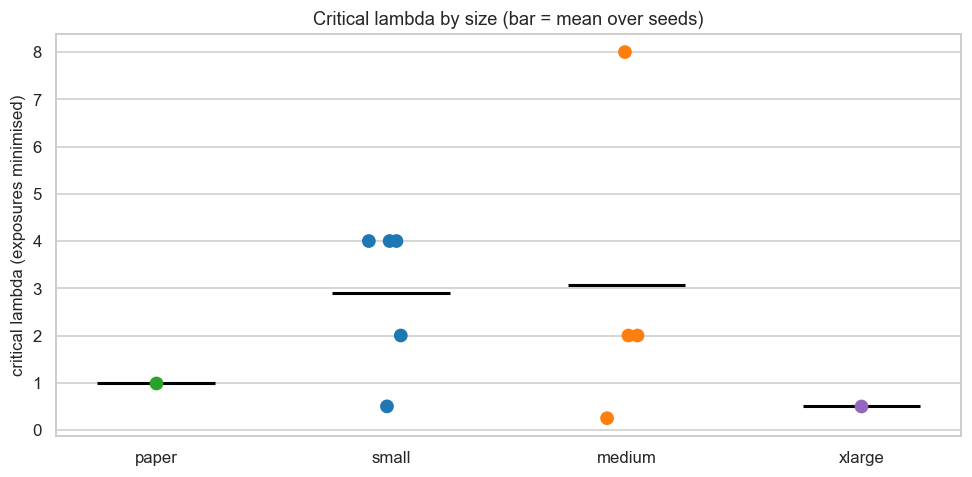

In [10]:
def critical_lambda_table(df):
    s1 = df.drop_duplicates(["instance_name", "lambda_rel"])
    rows = []
    for inst, g in s1.groupby("instance_name"):
        g = g.sort_values("lambda_rel")
        emin = g["exposure_count"].min()
        e0 = g.loc[g["lambda_rel"] == 0, "exposure_count"]
        e0 = e0.iloc[0] if len(e0) else np.nan
        hit = g[g["exposure_count"] <= emin]
        crit = hit["lambda_rel"].min() if not hit.empty else np.nan
        # exclude trivial case where lambda=0 already minimal
        crit_nontrivial = np.nan if (emin == e0) else crit
        w = g.loc[g["lambda_rel"] == crit, "weight"]
        rows.append({
            "instance": inst,
            "size": g["instance_size"].iloc[0],
            "exp_at_0": e0,
            "exp_min": emin,
            "critical_lambda": crit_nontrivial,
            "weight_at_crit": (w.iloc[0] if len(w) else np.nan),
        })
    out = pd.DataFrame(rows).sort_values(["size", "instance"])
    return out

crit = critical_lambda_table(df)
display(crit)

def plot_critical_lambda(crit):
    sub = crit.dropna(subset=["critical_lambda"])
    if sub.empty:
        print("No non-trivial critical lambda found.")
        return
    fig, ax = plt.subplots(figsize=(9, 4.5))
    sns.stripplot(data=sub, x="size", y="critical_lambda", hue="size",
                  order=[s for s in SIZE_ORDER if s in set(sub["size"])],
                  palette=SIZE_COLOR, size=9, ax=ax, legend=False)
    means = sub.groupby("size", observed=True)["critical_lambda"].mean()
    for i, size in enumerate([s for s in SIZE_ORDER if s in means.index]):
        ax.hlines(means[size], i - 0.25, i + 0.25, color="black", linewidth=2)
    ax.set_ylabel("critical lambda (exposures minimised)")
    ax.set_xlabel("")
    ax.set_title("Critical lambda by size (bar = mean over seeds)")
    fig.tight_layout(); plt.show()

plot_critical_lambda(crit)


## 2. Stage-2 packing configs across lambda

Trip-level metrics, comparing `baseline / mixed / even / full` as lambda
varies.

### 2.1 R_1 vs lambda, one panel per size, one line per config

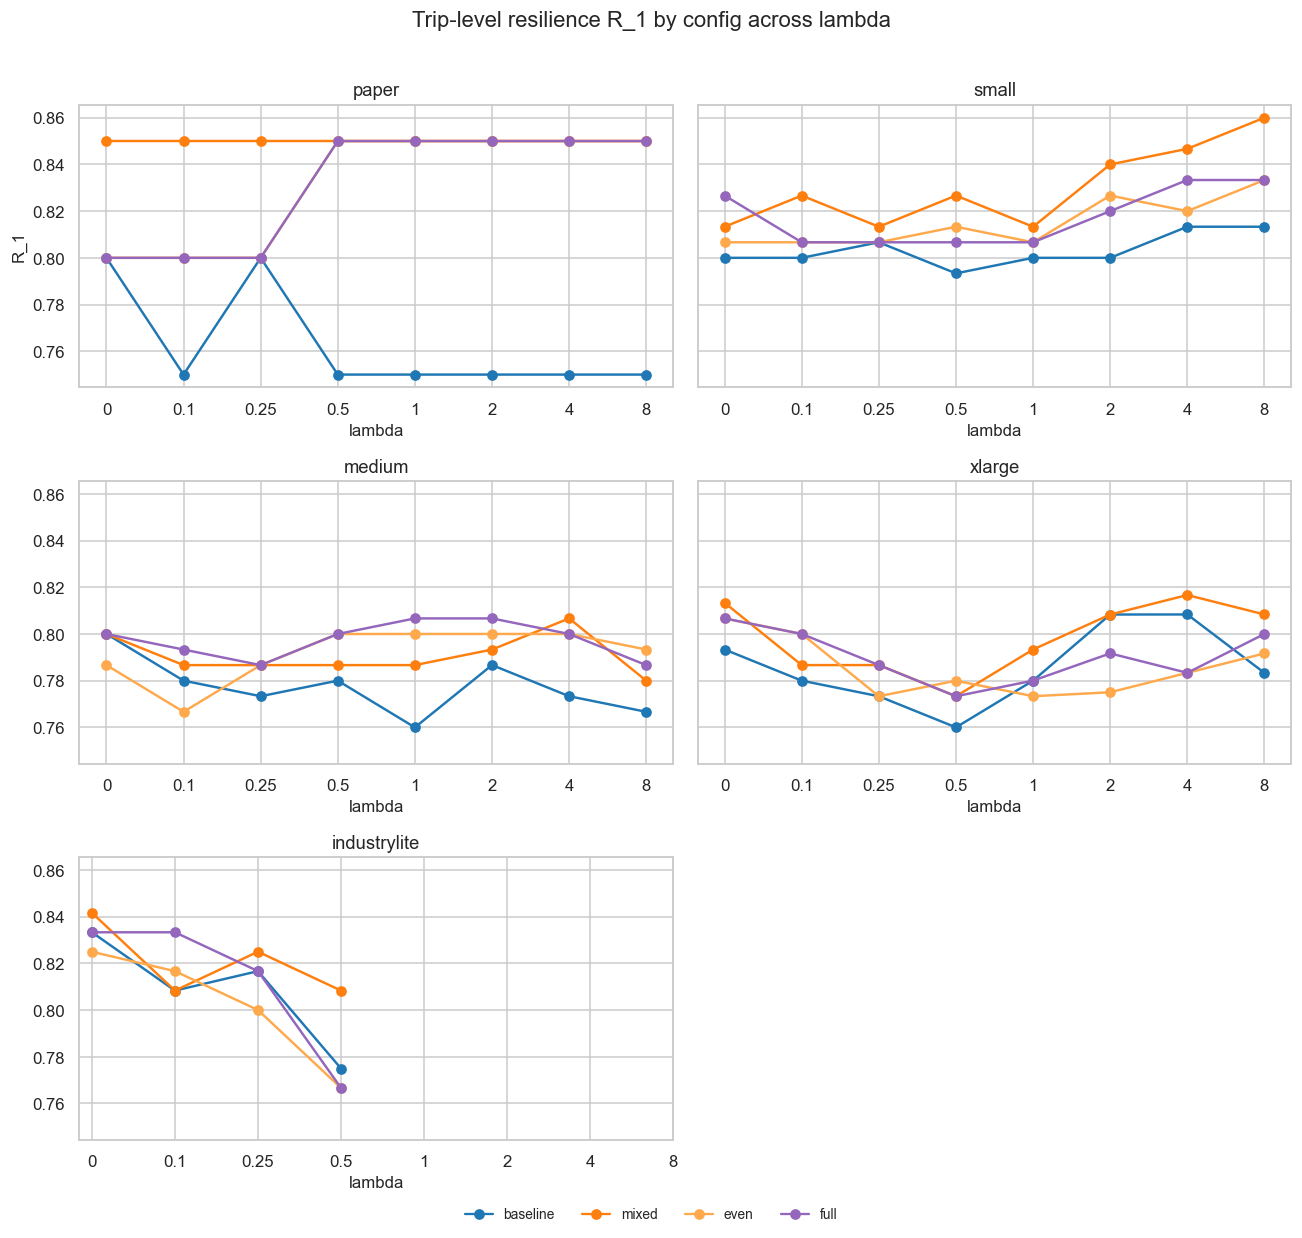

In [11]:
def plot_r1_vs_lambda(df):
    n = len(present_sizes)
    cols = min(2, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.6 * rows),
                             squeeze=False, sharey=True)
    for ax, size in zip(axes.flat, present_sizes):
        s = df[df["instance_size"] == size]
        for cfg in CONFIG_ORDER:
            g = (s[s["s2_config"] == cfg]
                 .groupby("lambda_rel")["r_1"].mean().reset_index())
            if g.empty:
                continue
            x = np.arange(len(g))
            ax.plot(x, g["r_1"], marker="o", color=CONFIG_COLOR[cfg],
                    label=cfg, linewidth=1.6)
        ax.set_xticks(range(len(LAMBDAS)))
        ax.set_xticklabels([f"{v:g}" for v in LAMBDAS])
        ax.set_title(size); ax.set_xlabel("lambda")
    axes.flat[0].set_ylabel("R_1")
    for ax in axes.flat[n:]:
        ax.set_visible(False)
    handles = [plt.Line2D([], [], color=CONFIG_COLOR[c], marker="o", label=c)
               for c in CONFIG_ORDER]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.suptitle("Trip-level resilience R_1 by config across lambda", y=1.01)
    fig.tight_layout(); plt.show()

plot_r1_vs_lambda(df)


### 2.2 Mono-part & concentrated trip counts vs lambda

These are exactly what the `mixed` (mono) and `even` (concentrated) soft
constraints target. Averaged over sizes; one line per config.

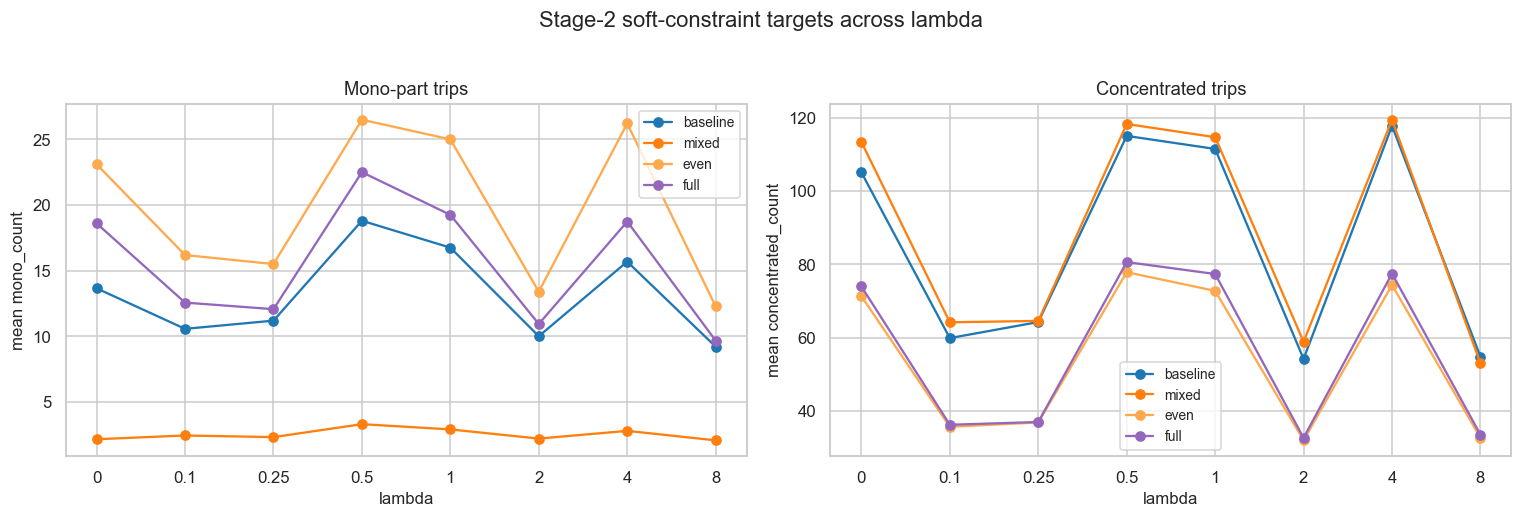

In [12]:
def plot_soft_counts_vs_lambda(df):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
    for ax, metric, title in [(axes[0], "mono_count", "Mono-part trips"),
                              (axes[1], "concentrated_count", "Concentrated trips")]:
        for cfg in CONFIG_ORDER:
            g = (df[df["s2_config"] == cfg]
                 .groupby("lambda_rel")[metric].mean().reset_index())
            x = np.arange(len(g))
            ax.plot(x, g[metric], marker="o", color=CONFIG_COLOR[cfg], label=cfg)
        ax.set_xticks(range(len(LAMBDAS)))
        ax.set_xticklabels([f"{v:g}" for v in LAMBDAS])
        ax.set_xlabel("lambda"); ax.set_ylabel(f"mean {metric}")
        ax.set_title(title); ax.legend()
    fig.suptitle("Stage-2 soft-constraint targets across lambda", y=1.02)
    fig.tight_layout(); plt.show()

plot_soft_counts_vs_lambda(df)


### 2.3 Dispatch cost saving (%) vs lambda, per config

How much of the Stage-1 dispatch cost Stage-2 packing recovers. `even`/`full`
tend to forfeit savings; `mixed` tends to keep them.

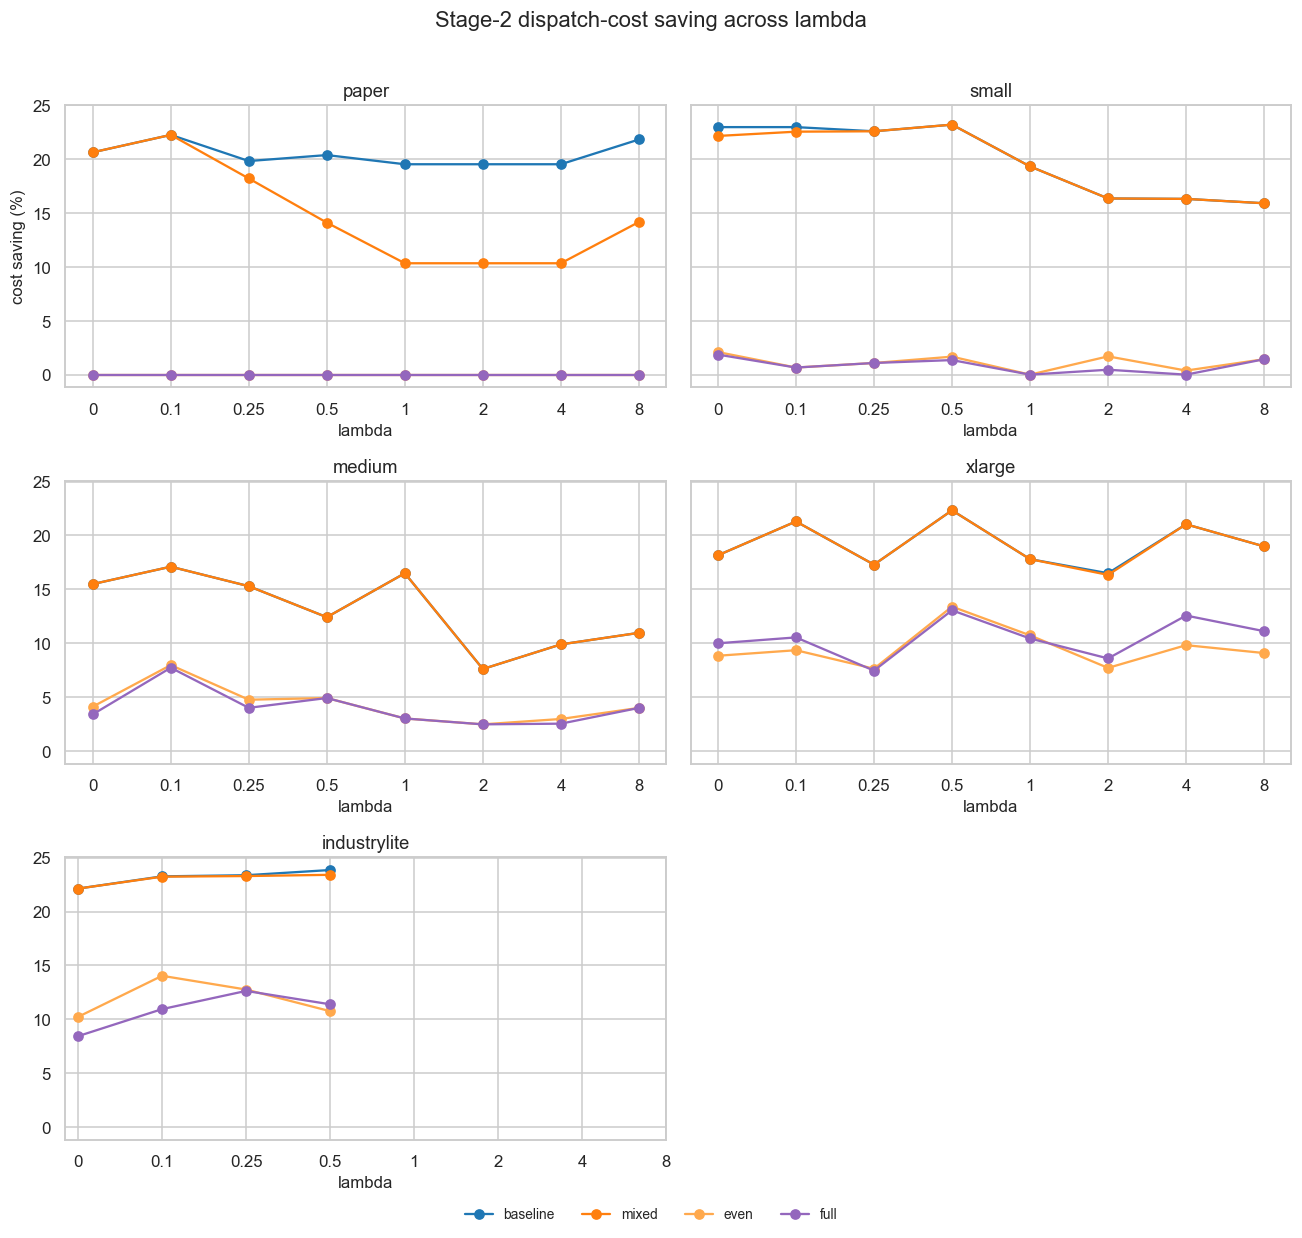

In [13]:
def plot_saving_vs_lambda(df):
    n = len(present_sizes)
    cols = min(2, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.6 * rows),
                             squeeze=False, sharey=True)
    for ax, size in zip(axes.flat, present_sizes):
        s = df[df["instance_size"] == size]
        for cfg in CONFIG_ORDER:
            g = (s[s["s2_config"] == cfg]
                 .groupby("lambda_rel")["cost_saving_pct"].mean().reset_index())
            x = np.arange(len(g))
            ax.plot(x, g["cost_saving_pct"], marker="o",
                    color=CONFIG_COLOR[cfg], label=cfg)
        ax.set_xticks(range(len(LAMBDAS)))
        ax.set_xticklabels([f"{v:g}" for v in LAMBDAS])
        ax.set_title(size); ax.set_xlabel("lambda")
    axes.flat[0].set_ylabel("cost saving (%)")
    for ax in axes.flat[n:]:
        ax.set_visible(False)
    handles = [plt.Line2D([], [], color=CONFIG_COLOR[c], marker="o", label=c)
               for c in CONFIG_ORDER]
    fig.legend(handles=handles, loc="lower center", ncol=4,
               bbox_to_anchor=(0.5, -0.02), frameon=False)
    fig.suptitle("Stage-2 dispatch-cost saving across lambda", y=1.01)
    fig.tight_layout(); plt.show()

plot_saving_vs_lambda(df)


### 2.4 K_1 vs R_1 — kit bottleneck vs trip resilience

On 2-part instances K_1 collapses onto R_1 (dashed identity line); on
part-richer classes it should separate.

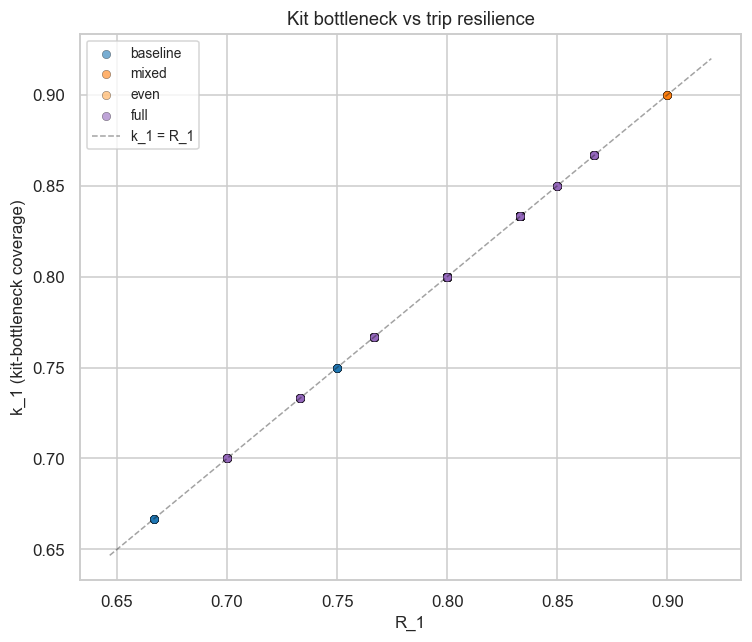

In [14]:
def plot_k1_vs_r1(df):
    fig, ax = plt.subplots(figsize=(7, 6))
    for cfg in CONFIG_ORDER:
        s = df[df["s2_config"] == cfg]
        ax.scatter(s["r_1"], s["k_1"], s=30, alpha=0.6,
                   color=CONFIG_COLOR[cfg], edgecolor="black", linewidth=0.3,
                   label=cfg)
    lo = min(df["r_1"].min(), df["k_1"].min()) - 0.02
    hi = max(df["r_1"].max(), df["k_1"].max()) + 0.02
    ax.plot([lo, hi], [lo, hi], "k--", alpha=0.4, linewidth=1, label="k_1 = R_1")
    ax.set_xlabel("R_1"); ax.set_ylabel("k_1 (kit-bottleneck coverage)")
    ax.set_title("Kit bottleneck vs trip resilience")
    ax.legend()
    fig.tight_layout(); plt.show()

plot_k1_vs_r1(df)


## 3. Partial-disruption resilience R_alpha

Coverage after losing an alpha fraction of capacity, single-arc and global
variants.

### 3.1 R_alpha curves at low vs high lambda

Dashed = lambda=0, solid = max lambda. One panel per size, one colour per
config. Where the dashed line sits above the solid line, the high weight
*hurt* R_alpha at that alpha.

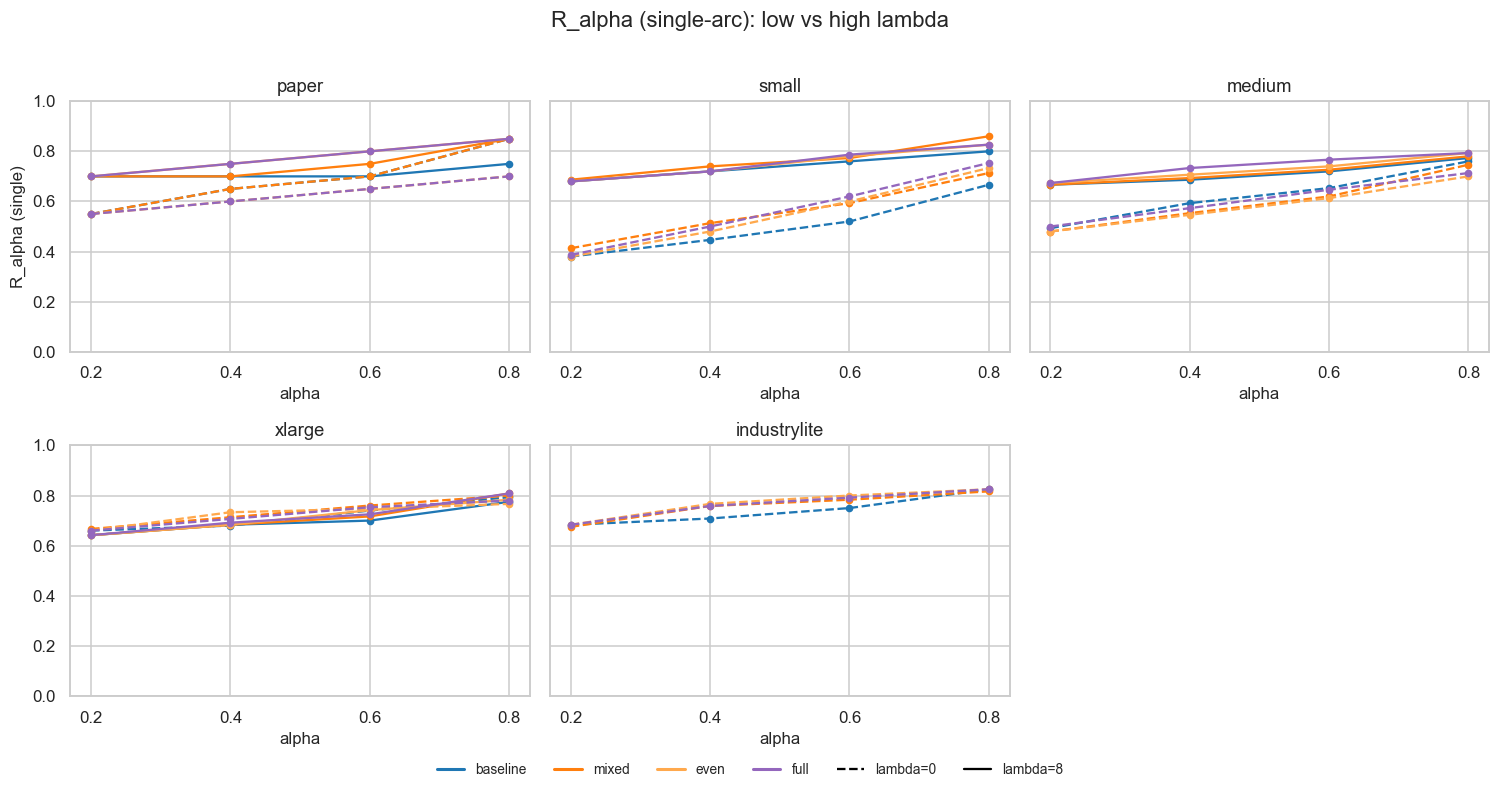

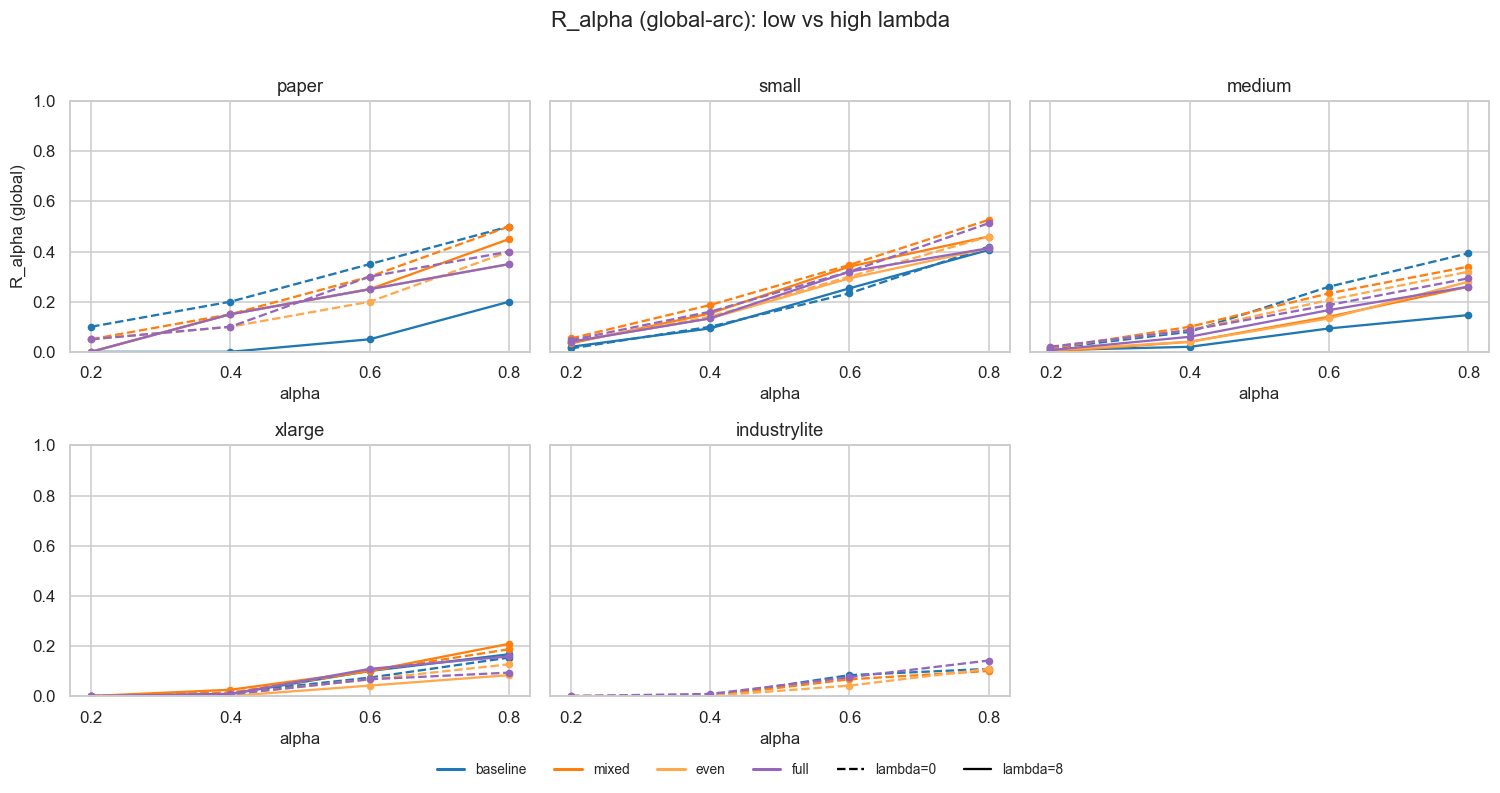

In [15]:
def plot_ralpha_curves(df, mode="single"):
    lo, hi = min(LAMBDAS), max(LAMBDAS)
    n = len(present_sizes)
    cols = min(3, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4.6 * cols, 3.4 * rows),
                             squeeze=False, sharey=True)
    for ax, size in zip(axes.flat, present_sizes):
        s = df[df["instance_size"] == size]
        for cfg in CONFIG_ORDER:
            for lam, style in [(lo, "--"), (hi, "-")]:
                cs = s[(s["s2_config"] == cfg) & (s["lambda_rel"] == lam)]
                if cs.empty:
                    continue
                ys = [cs[f"r_heaviest_{mode}_{a}"].mean() for a in ALPHAS]
                ax.plot(ALPHAS, ys, style, marker="o", color=CONFIG_COLOR[cfg],
                        linewidth=1.5, markersize=4)
        ax.set_xticks(ALPHAS); ax.set_xlabel("alpha"); ax.set_title(size)
        ax.set_ylim(0, 1)
    axes.flat[0].set_ylabel(f"R_alpha ({mode})")
    for ax in axes.flat[n:]:
        ax.set_visible(False)
    handles = [plt.Line2D([], [], color=CONFIG_COLOR[c], lw=2, label=c)
               for c in CONFIG_ORDER]
    handles += [plt.Line2D([], [], color="black", lw=1.5, ls="--", label=f"lambda={lo:g}"),
                plt.Line2D([], [], color="black", lw=1.5, ls="-", label=f"lambda={hi:g}")]
    fig.legend(handles=handles, loc="lower center", ncol=6,
               bbox_to_anchor=(0.5, -0.03), frameon=False)
    fig.suptitle(f"R_alpha ({mode}-arc): low vs high lambda", y=1.01)
    fig.tight_layout(); plt.show()

plot_ralpha_curves(df, "single")
plot_ralpha_curves(df, "global")


### 3.2 R_alpha area-under-curve vs lambda

Trapezoidal integral of R_alpha over alpha in [0.2, 0.8] — one robustness
number per row — plotted against lambda, one line per config (averaged over
sizes).

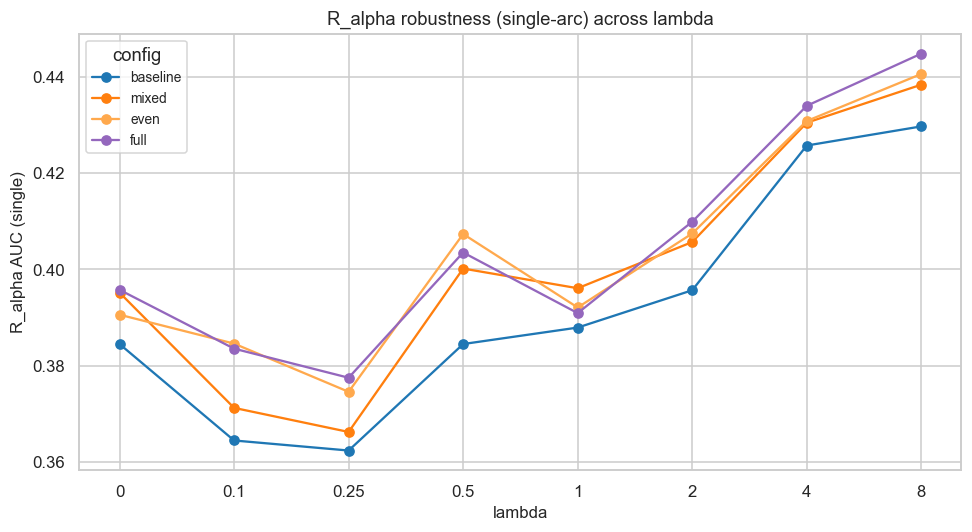

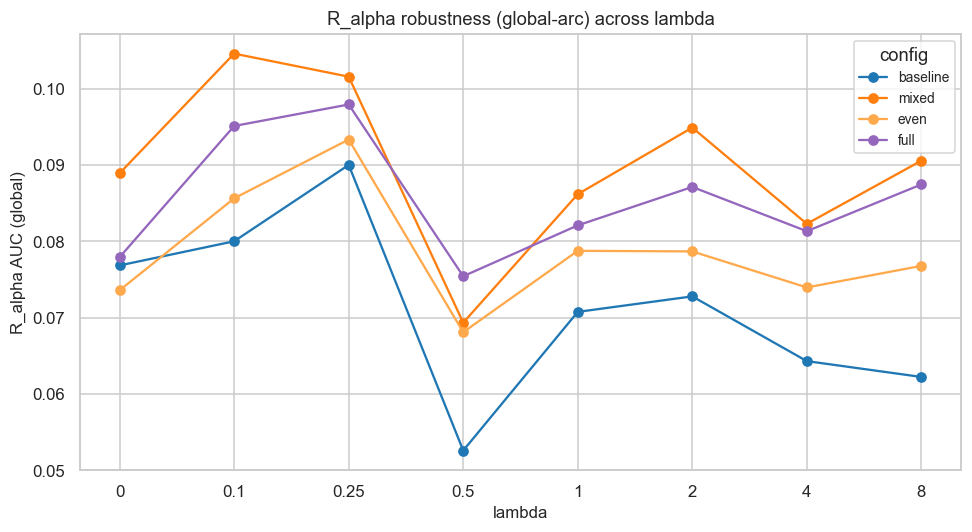

In [16]:
def plot_ralpha_auc_vs_lambda(df, mode="single"):
    trapz = getattr(np, "trapezoid", None) or np.trapz
    cols = [f"r_heaviest_{mode}_{a}" for a in ALPHAS]
    sub = df.copy()
    sub["auc"] = trapz(sub[cols].values, x=ALPHAS, axis=1)
    fig, ax = plt.subplots(figsize=(9, 5))
    for cfg in CONFIG_ORDER:
        g = sub[sub["s2_config"] == cfg].groupby("lambda_rel")["auc"].mean().reset_index()
        x = np.arange(len(g))
        ax.plot(x, g["auc"], marker="o", color=CONFIG_COLOR[cfg], label=cfg)
    ax.set_xticks(range(len(LAMBDAS)))
    ax.set_xticklabels([f"{v:g}" for v in LAMBDAS])
    ax.set_xlabel("lambda"); ax.set_ylabel(f"R_alpha AUC ({mode})")
    ax.set_title(f"R_alpha robustness ({mode}-arc) across lambda")
    ax.legend(title="config")
    fig.tight_layout(); plt.show()

plot_ralpha_auc_vs_lambda(df, "single")
plot_ralpha_auc_vs_lambda(df, "global")


### 3.3 R_alpha heatmap (size x alpha) at high lambda

One tile per (size, alpha) for the `mixed` config at the largest lambda.
Greener = more demand still coverable after losing that fraction of
capacity. Reads off the degradation profile per size at a glance.

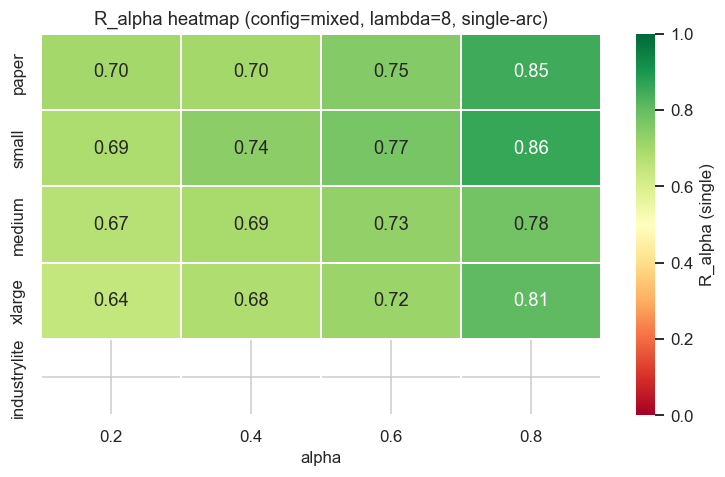

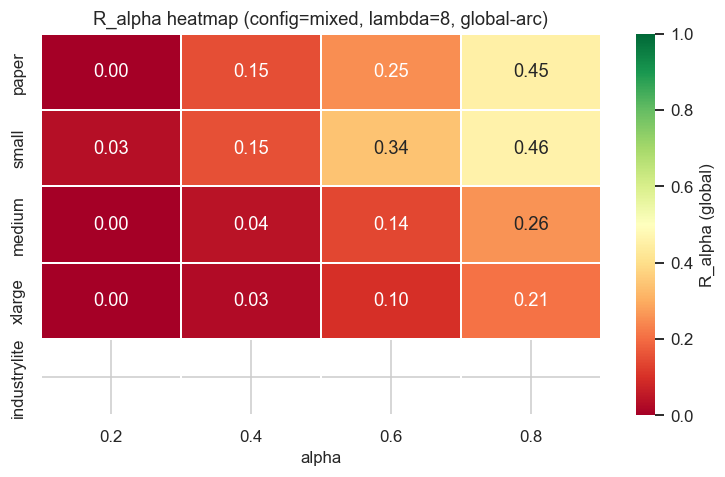

In [17]:
def plot_ralpha_heatmap(df, lam=None, config="mixed", mode="global"):
    if lam is None:
        lam = max(LAMBDAS)
    cols = [f"r_heaviest_{mode}_{a}" for a in ALPHAS]
    sub = df[(df["s2_config"] == config) & (df["lambda_rel"] == lam)]
    if sub.empty:
        print(f"[SKIP] no rows for config={config}, lambda={lam}")
        return
    mat = (sub.groupby("instance_size", observed=True)[cols].mean()
              .reindex(present_sizes))
    mat.columns = [str(a) for a in ALPHAS]
    fig, ax = plt.subplots(figsize=(7, 0.5 * len(present_sizes) + 2))
    sns.heatmap(mat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
                ax=ax, linewidths=0.3, linecolor="white",
                cbar_kws={"label": f"R_alpha ({mode})"})
    ax.set_xlabel("alpha"); ax.set_ylabel("")
    ax.set_title(f"R_alpha heatmap (config={config}, lambda={lam:g}, {mode}-arc)")
    fig.tight_layout(); plt.show()

plot_ralpha_heatmap(df, config="mixed", mode="single")
plot_ralpha_heatmap(df, config="mixed", mode="global")


### 3.4 R_alpha cost-tradeoff frontier — the price of disruption tolerance

One figure per size, one line per config, connecting the **smallest and
largest lambda** (the two endpoints of the sweep; point labels show the
lambda value). X = R_alpha at alpha=0.8 (%); Y = Stage-2 dispatch cost
increase vs the (baseline, lambda=0) anchor (%). Reads as "how much extra
dispatch do you pay to tolerate an 80% capacity loss?" — the direct
cost-of-resilience curve for the thesis.

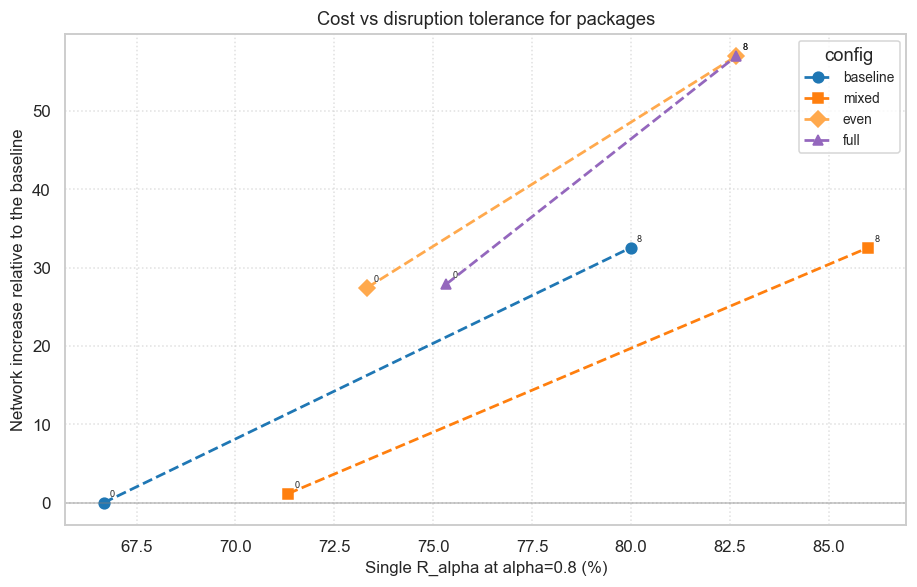

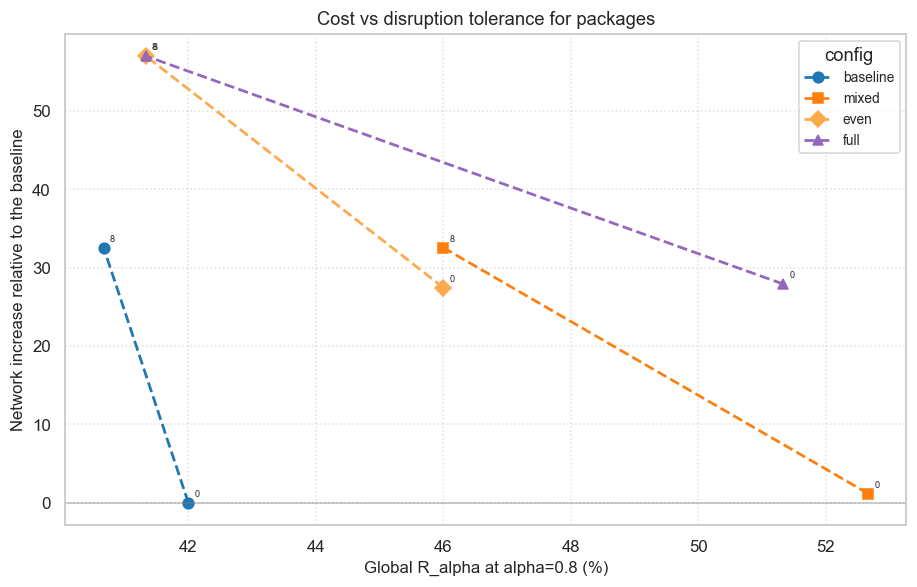

In [18]:
def plot_ralpha_cost_tradeoff(df, alpha=0.8, mode="global"):
    col = f"r_heaviest_{mode}_{alpha}"
    if col not in df.columns:
        print(f"[SKIP] missing {col}")
        return
    markers = {"baseline": "o", "mixed": "s", "even": "D", "full": "^"}
    lam_lo, lam_hi = min(LAMBDAS), max(LAMBDAS)
    instances_focus =  ['small']
    sub = df[df["instance_size"].isin(instances_focus)]
    present_sizes = [s for s in instances_focus if s in set(df["instance_size"])]
    for size in present_sizes:
        sub = df[df["instance_size"] == size]
        ref = sub[(sub["lambda_rel"] == 0) & (sub["s2_config"] == "baseline")]
        if ref.empty:
            continue
        c0 = ref["s2_dispatch_cost"].mean()
        if not c0:
            continue
        fig, ax = plt.subplots(figsize=(8.5, 5.5))
        for cfg in CONFIG_ORDER:
            g = (sub[sub["s2_config"] == cfg]
                 .groupby("lambda_rel")
                 .agg(r=(col, "mean"), cost=("s2_dispatch_cost", "mean"))
                 .reset_index().sort_values("lambda_rel"))
            # endpoints only: smallest and largest lambda
            g = g[g["lambda_rel"].isin([lam_lo, lam_hi])]
            if g.empty:
                continue
            r_vals = g["r"] * 100
            cost_pct = (g["cost"] - c0) / c0 * 100
            ax.plot(r_vals, cost_pct, f"{markers[cfg]}--", linewidth=1.8,
                    markersize=7, color=CONFIG_COLOR[cfg], label=cfg)
            for lam, rv, cv in zip(g["lambda_rel"], r_vals, cost_pct):
                ax.annotate(f"{lam:g}", (rv, cv), textcoords="offset points",
                            xytext=(4, 4), fontsize=6)
        ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
        ax.set_xlabel(f"{mode.title()} R_alpha at alpha={alpha} (%)")
        ax.set_ylabel("Network increase relative to the baseline")
        ax.set_title(f"Cost vs disruption tolerance for packages")
        ax.grid(True, linestyle=":", alpha=0.6)
        ax.legend(title="config", fontsize=9)
        fig.tight_layout(); plt.show()

plot_ralpha_cost_tradeoff(df, alpha=0.8, mode="single")
plot_ralpha_cost_tradeoff(df, alpha=0.8, mode="global")


## 4. Cost vs resilience frontiers

Tracing the whole lambda path in the (resilience, cost) plane, rather than
just two endpoints.

### 4.1 Cost vs R_TR frontier for a single size (baseline config)

One size class at a time. Each point is one lambda (labelled); the line
walks lambda from 0 upward. X = Stage-1 cost increase vs lambda=0, Y = mean
R_TR. Up-and-to-the-left along the curve = more resilience bought per unit
of cost.

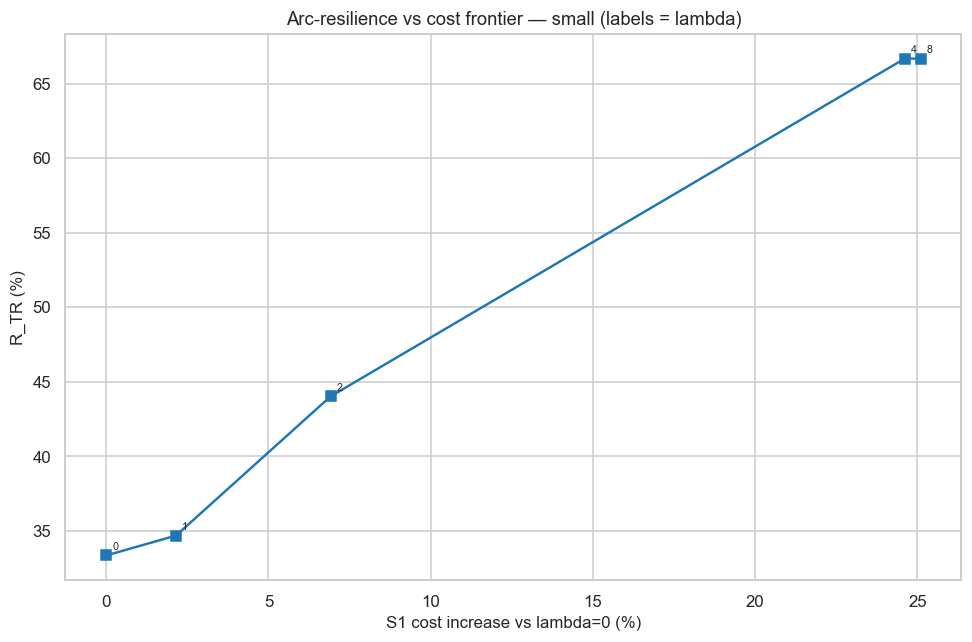

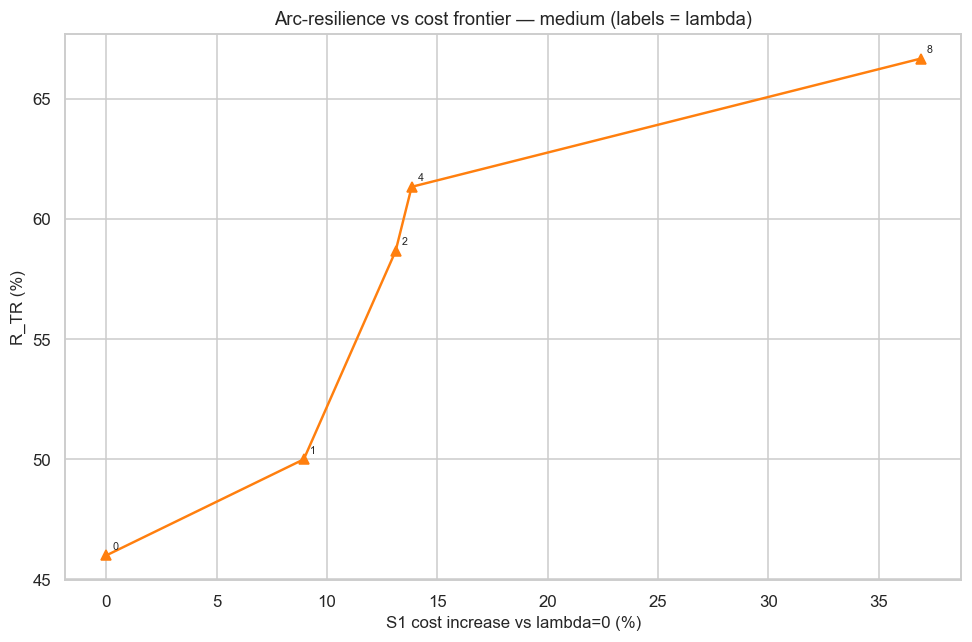

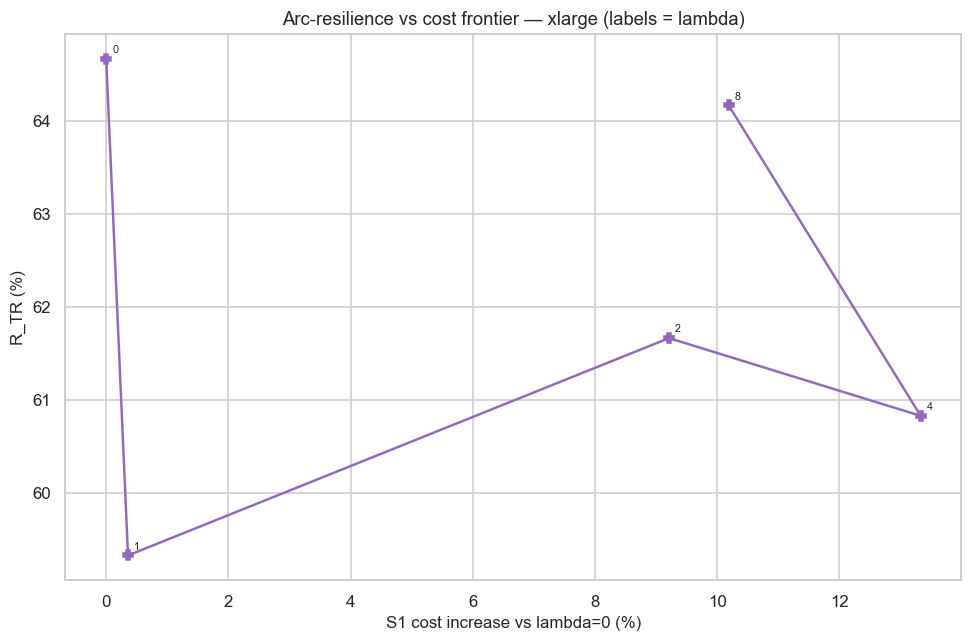

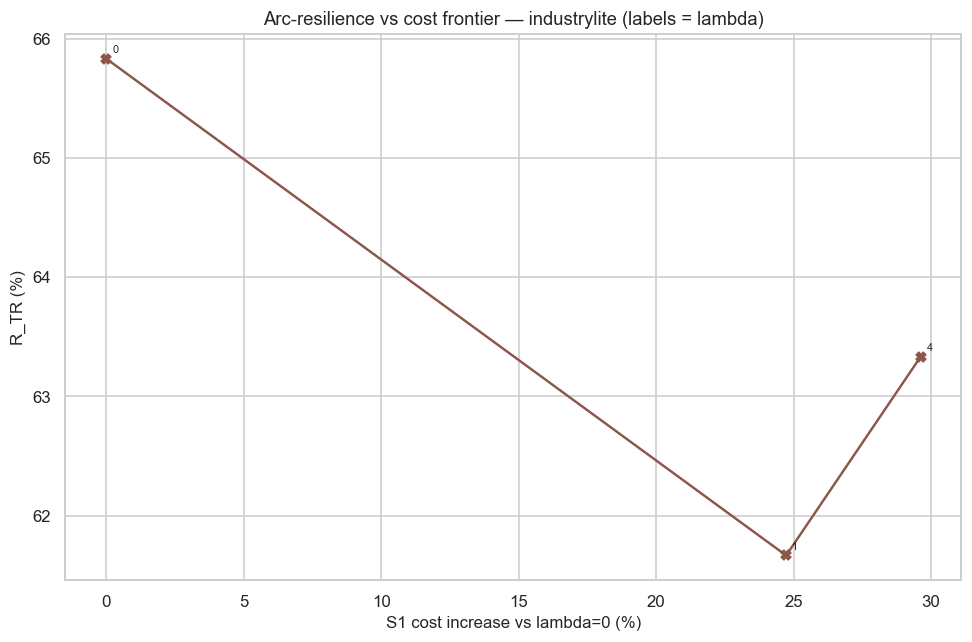

In [49]:
def plot_cost_vs_rtr_frontier(df, size="small"):
    s1 = df.drop_duplicates(["instance_name", "lambda_rel"])
    s = s1[s1["instance_size"] == size]
    lamda_filter = [0,1,2,4,8]
    s = s[s["lambda_rel"].isin(lamda_filter)]
    if s.empty:
        print(f"[SKIP] no rows for size={size}")
        return
    g = (s.groupby("lambda_rel")
           .agg(rtr=("r_tr", "mean"), prem=("s1_cost_premium_pct", "mean"))
           .reset_index().sort_values("lambda_rel"))
    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(g["prem"], g["rtr"] * 100, marker=SIZE_MARKER.get(size, "o"),
            color=SIZE_COLOR.get(size, "#1f77b4"), linewidth=1.6)
    for _, r in g.iterrows():
        ax.annotate(f"{r['lambda_rel']:g}", (r["prem"], r["rtr"] * 100),
                    textcoords="offset points", xytext=(4, 4), fontsize=7)
    ax.set_xlabel("S1 cost increase vs lambda=0 (%)")
    ax.set_ylabel("R_TR (%)")
    ax.set_title(f"Arc-resilience vs cost frontier — {size} (labels = lambda)")
    fig.tight_layout(); plt.show()

plot_cost_vs_rtr_frontier(df, "small")
plot_cost_vs_rtr_frontier(df, "medium")
plot_cost_vs_rtr_frontier(df, "xlarge")
plot_cost_vs_rtr_frontier(df, "industrylite")


### 4.2 Cost increase vs R_TR — all sizes overlaid (Stage-2 realised cost)

Companion to 4.1, but on the **Stage-2 realised dispatch cost** (config =
baseline) rather than the Stage-1 routing cost. One line per size walking
lambda (point labels), Y anchored to each size's own lambda=0. Shows what
you actually pay after packing to gain arc-level resilience.

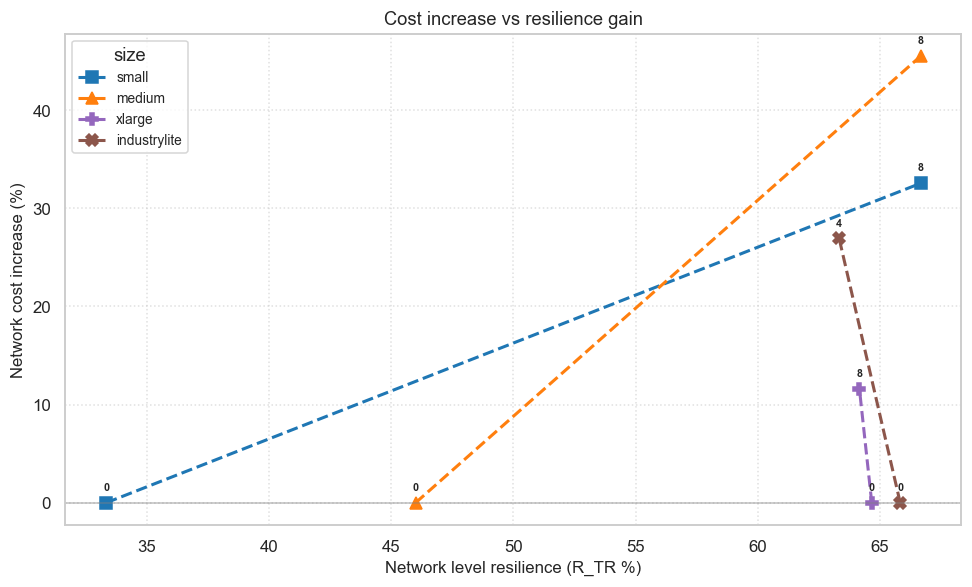

In [86]:
def plot_cost_increase_vs_rtr(df):
    sub = df[df["s2_config"] == "baseline"].copy()

    # per-size lambda selection
    lambda_map = {
        "small":        [0, 8],
        "medium":       [0, 8],
        "xlarge":       [0, 8],
        "industrylite": [0, 4],
    }

    instances_focus = list(lambda_map.keys())
    sub = sub[sub["instance_size"].isin(instances_focus)]

    sizes = [s for s in SIZE_ORDER if (sub["instance_size"] == s).any()]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    for size in sizes:
        s = sub[sub["instance_size"] == size]
        s = s[s["lambda_rel"].isin(lambda_map[size])]   # <-- per-size filter

        ref = s[s["lambda_rel"] == 0]
        if ref.empty:
            continue
        c0 = ref["s2_dispatch_cost"].mean()
        if not c0:
            continue
        g = (s.groupby("lambda_rel")
               .agg(rtr=("r_tr", "mean"), cost=("s2_dispatch_cost", "mean"))
               .reset_index().sort_values("lambda_rel"))
        rtrs = g["rtr"] * 100
        pcts = (g["cost"] - c0) / c0 * 100
        ax.plot(rtrs, pcts, "--", linewidth=2, markersize=8,
                color=SIZE_COLOR[size], marker=SIZE_MARKER[size], label=size)
        for lam, rtr, pct in zip(g["lambda_rel"], rtrs, pcts):
            ax.annotate(f"{lam:g}", (rtr, pct), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=7, fontweight="bold")
    ax.axhline(0, color="gray", linewidth=1, alpha=0.5)
    ax.set_xlabel("Network level resilience (R_TR %)")
    ax.set_ylabel("Network cost increase (%)")
    ax.set_title("Cost increase vs resilience gain")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(title="size", fontsize=9)
    fig.tight_layout(); plt.show()

plot_cost_increase_vs_rtr(df)

### 4.3 Pareto view — cost vs R_TR coloured by lambda

Per size, every (instance, lambda) point; colour encodes lambda. Shows the
attainable cost/resilience set and how lambda moves you along it.

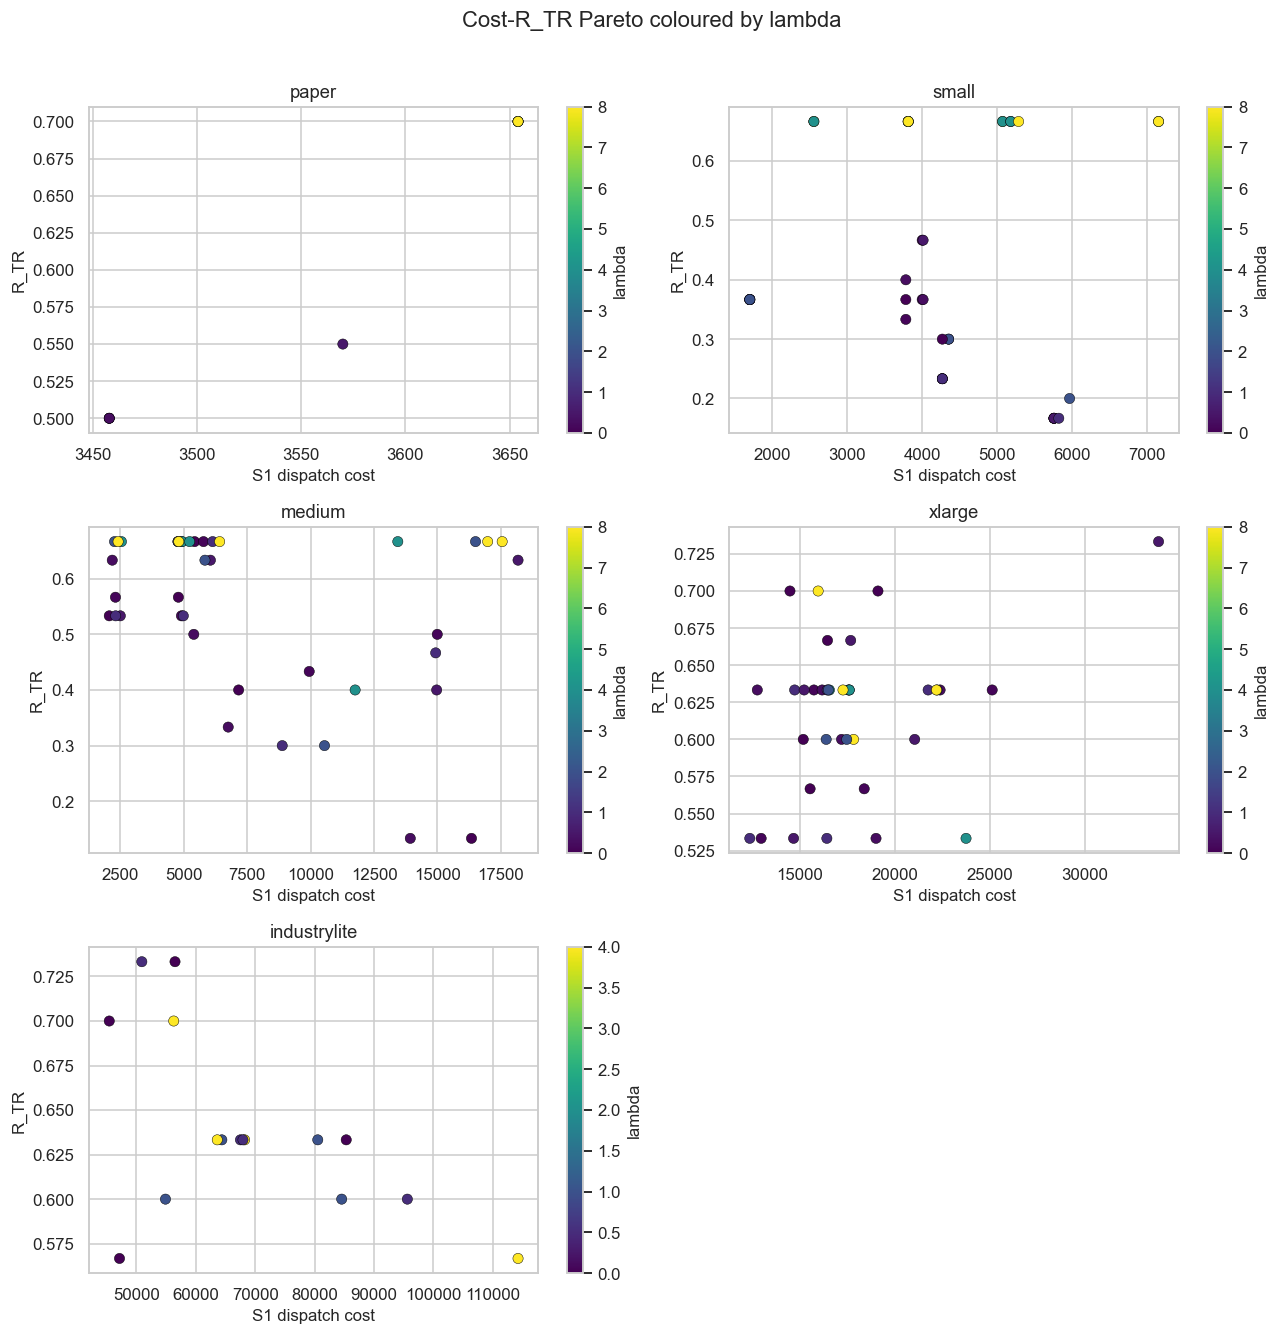

In [87]:
def plot_pareto_by_lambda(df):
    s1 = df.drop_duplicates(["instance_name", "lambda_rel"])
    n = len(present_sizes)
    cols = min(2, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows),
                             squeeze=False)
    for ax, size in zip(axes.flat, present_sizes):
        s = s1[s1["instance_size"] == size]
        sc = ax.scatter(s["s1_dispatch_cost"], s["r_tr"],
                        c=s["lambda_rel"], cmap="viridis", s=45,
                        edgecolor="black", linewidth=0.3)
        ax.set_xlabel("S1 dispatch cost"); ax.set_ylabel("R_TR")
        ax.set_title(size)
        fig.colorbar(sc, ax=ax, label="lambda")
    for ax in axes.flat[n:]:
        ax.set_visible(False)
    fig.suptitle("Cost-R_TR Pareto coloured by lambda", y=1.01)
    fig.tight_layout(); plt.show()

plot_pareto_by_lambda(df)


### 4.4 Is Stage-2 packing earning its cost?

For each non-baseline run, anchored to the matching `baseline` row (same
instance + lambda): relative cost change vs R_1 gain. Upper-right pays for
resilience, lower-right is a free lunch, upper-left is strictly dominated.

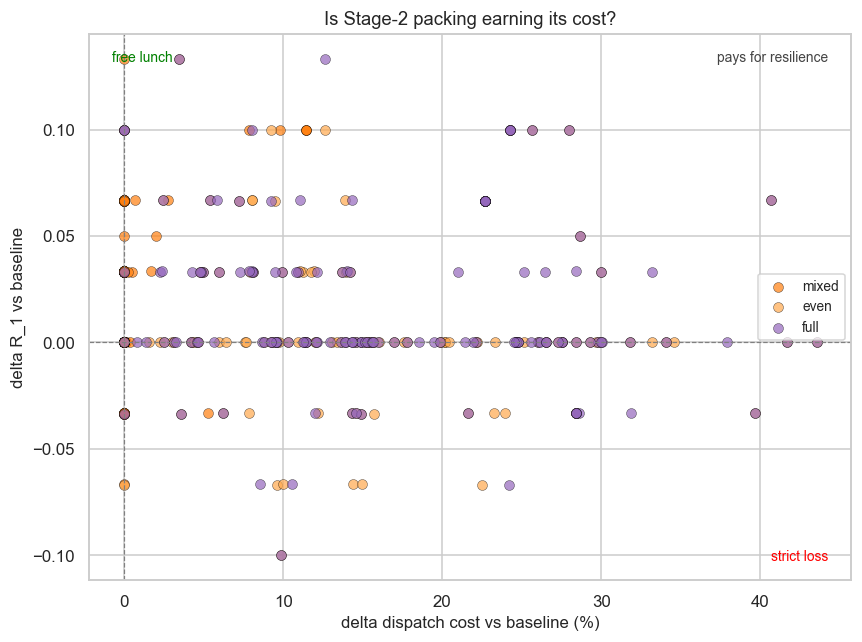

In [88]:
def plot_cost_vs_resilience_quadrant(df):
    base = (df[df["s2_config"] == "baseline"]
            .set_index(["instance_name", "lambda_rel"])[["s2_dispatch_cost", "r_1"]]
            .rename(columns={"s2_dispatch_cost": "base_cost", "r_1": "base_r1"}))
    m = df.join(base, on=["instance_name", "lambda_rel"], how="left")
    m = m[m["s2_config"] != "baseline"].copy()
    m = m[m["base_cost"] > 0]
    m["d_cost_pct"] = (m["s2_dispatch_cost"] - m["base_cost"]) / m["base_cost"] * 100
    m["d_r1"] = m["r_1"] - m["base_r1"]
    fig, ax = plt.subplots(figsize=(8, 6))
    for cfg in ["mixed", "even", "full"]:
        s = m[m["s2_config"] == cfg]
        ax.scatter(s["d_cost_pct"], s["d_r1"], s=42, alpha=0.7,
                   color=CONFIG_COLOR[cfg], edgecolor="black", linewidth=0.3,
                   label=cfg)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("delta dispatch cost vs baseline (%)")
    ax.set_ylabel("delta R_1 vs baseline")
    ax.text(0.97, 0.97, "pays for resilience", transform=ax.transAxes,
            ha="right", va="top", fontsize=9, color="#444")
    ax.text(0.03, 0.97, "free lunch", transform=ax.transAxes,
            ha="left", va="top", fontsize=9, color="green")
    ax.text(0.97, 0.03, "strict loss", transform=ax.transAxes,
            ha="right", va="bottom", fontsize=9, color="red")
    ax.set_title("Is Stage-2 packing earning its cost?")
    ax.legend()
    fig.tight_layout(); plt.show()

plot_cost_vs_resilience_quadrant(df)


## 5. Diagnostics — seed spread, correlations, timing, convergence

### 5.1 Seed spread of R_1 (config = mixed)

Per (size, lambda) we have up to 5 seeds; a wide box means the metric is
seed-sensitive and the per-class mean should be read with its sd.

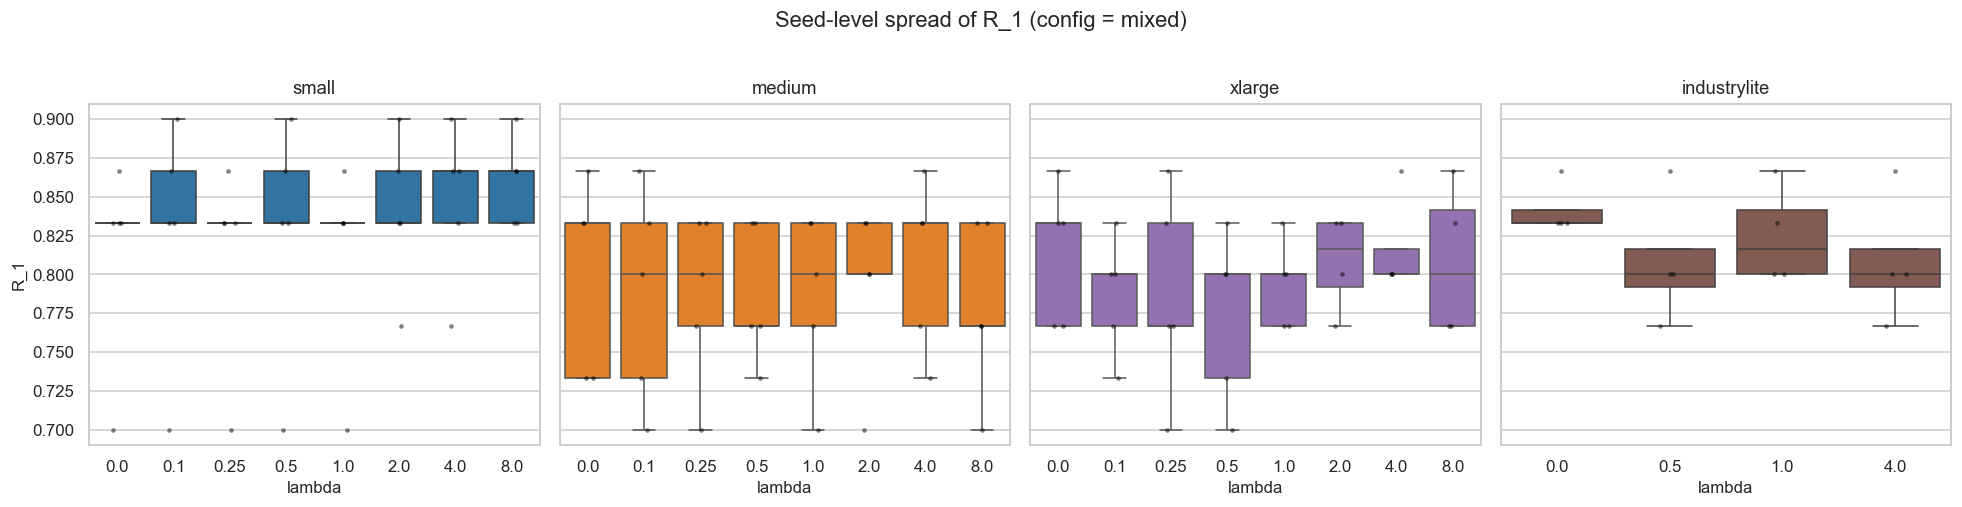

In [89]:
def plot_seed_variance(df):
    sub = df[(df["s2_config"] == "mixed") & (df["seed"] != 0)]
    multi = [s for s in present_sizes if sub[sub["instance_size"] == s]["seed"].nunique() > 1]
    if not multi:
        print("No multi-seed sizes with config=mixed.")
        return
    n = len(multi)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.5), squeeze=False, sharey=True)
    for ax, size in zip(axes[0], multi):
        s = sub[sub["instance_size"] == size]
        sns.boxplot(data=s, x="lambda_rel", y="r_1", ax=ax,
                    color=SIZE_COLOR[size], fliersize=0)
        sns.stripplot(data=s, x="lambda_rel", y="r_1", ax=ax,
                      color="black", size=3, alpha=0.5)
        ax.set_title(size); ax.set_xlabel("lambda")
    axes[0][0].set_ylabel("R_1")
    fig.suptitle("Seed-level spread of R_1 (config = mixed)", y=1.02)
    fig.tight_layout(); plt.show()

plot_seed_variance(df)


### 5.2 Metric correlations

Pearson correlations among the headline numeric columns (all rows).

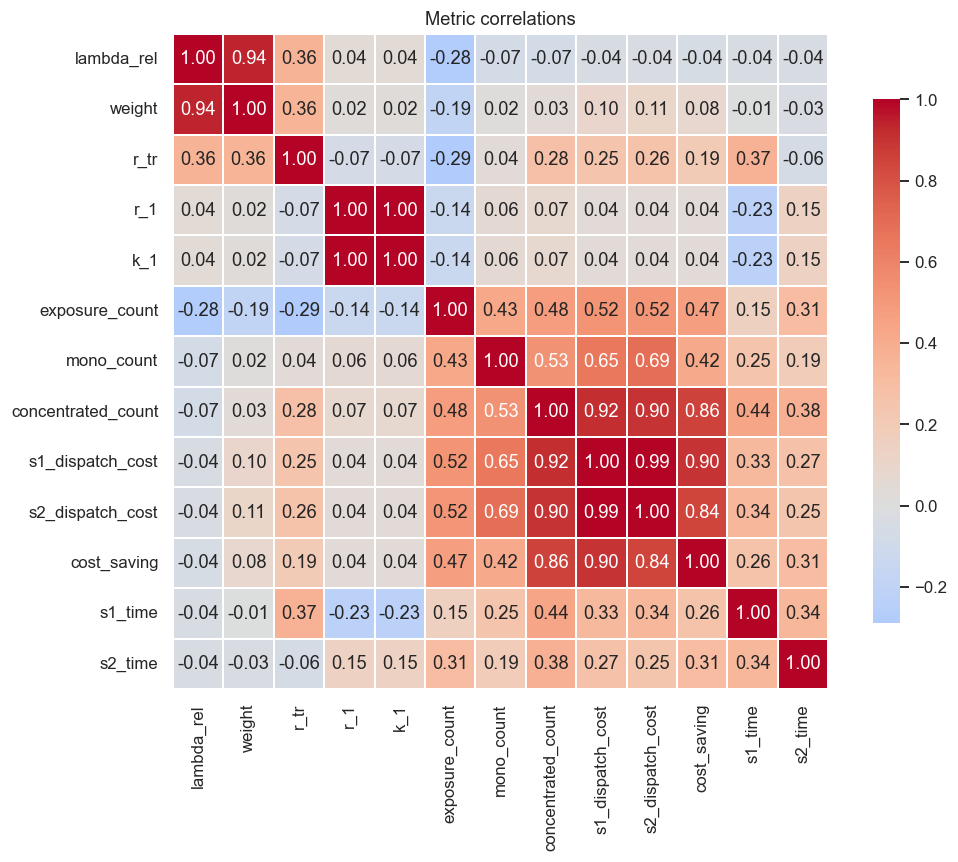

In [90]:
def plot_correlations(df):
    cols = ["lambda_rel", "weight", "r_tr", "r_1", "k_1",
            "exposure_count", "mono_count", "concentrated_count",
            "s1_dispatch_cost", "s2_dispatch_cost", "cost_saving",
            "s1_time", "s2_time"]
    cols = [c for c in cols if c in df.columns]
    corr = df[cols].corr(numeric_only=True)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                square=True, linewidths=0.3, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title("Metric correlations")
    fig.tight_layout(); plt.show()

plot_correlations(df)


### 5.3 Where wall-clock goes — stage time vs lambda

Stacked Stage-1 / Stage-2 mean time per (size, lambda). Recall Stage 1 was
often not proven optimal on the larger classes (Section 0), so its time is
hitting the limit there rather than converging.

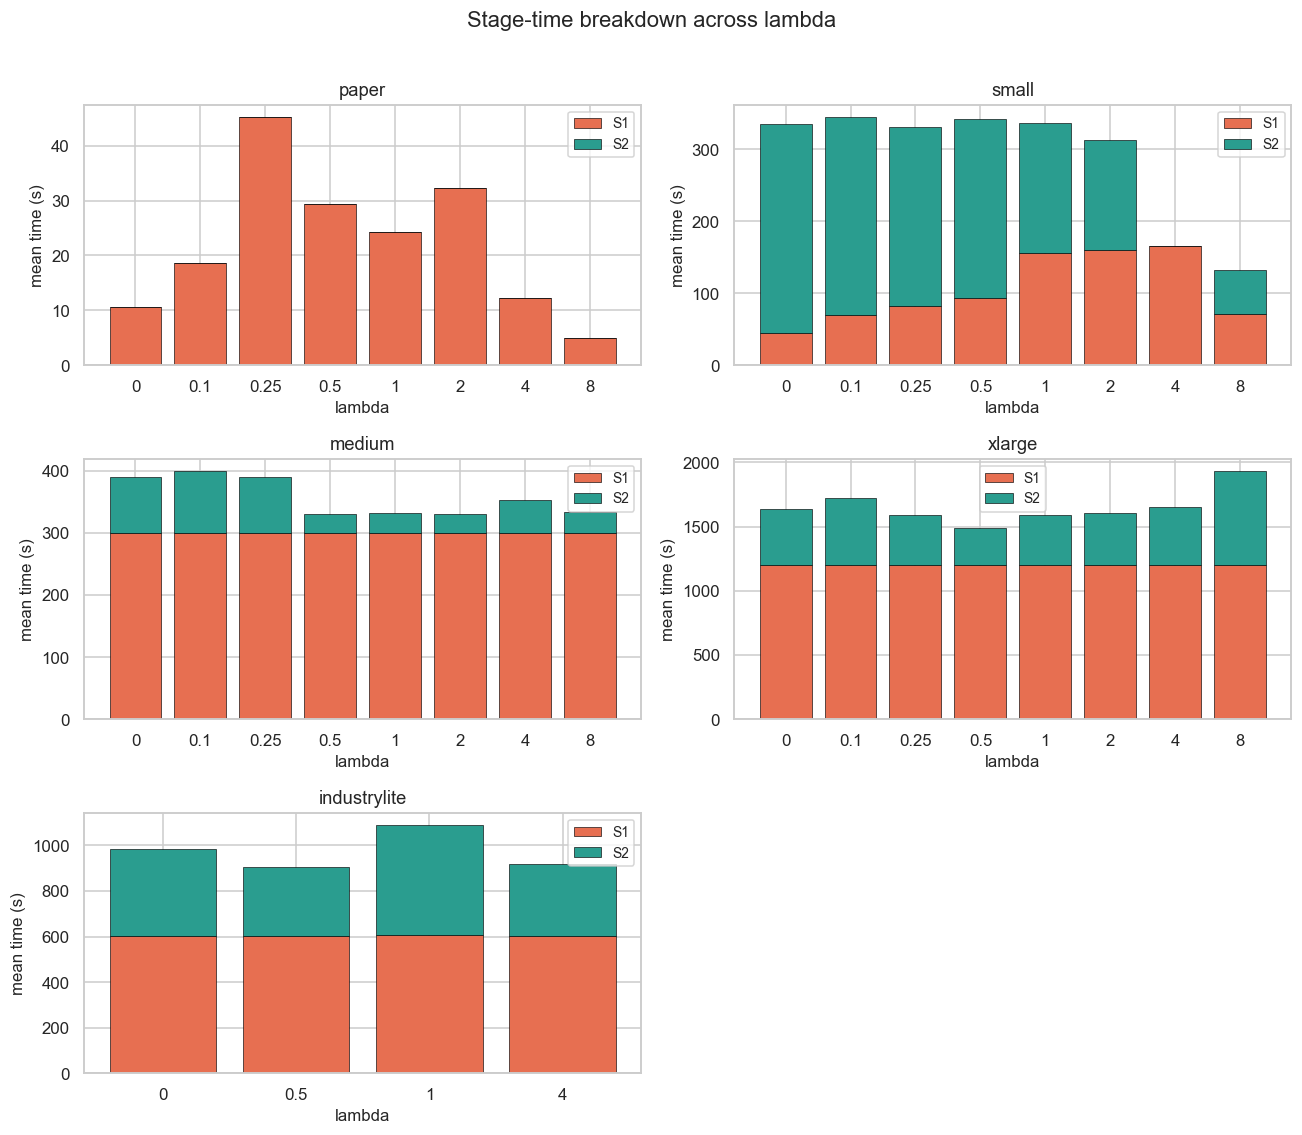

In [91]:
def plot_time_vs_lambda(df):
    n = len(present_sizes)
    cols = min(2, n)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 3.4 * rows),
                             squeeze=False)
    for ax, size in zip(axes.flat, present_sizes):
        s = df[df["instance_size"] == size]
        g = s.groupby("lambda_rel").agg(s1=("s1_time", "mean"),
                                        s2=("s2_time", "mean")).reset_index()
        x = np.arange(len(g))
        ax.bar(x, g["s1"], label="S1", color="#e76f51", edgecolor="black", linewidth=0.4)
        ax.bar(x, g["s2"], bottom=g["s1"], label="S2", color="#2a9d8f",
               edgecolor="black", linewidth=0.4)
        ax.set_xticks(x); ax.set_xticklabels([f"{v:g}" for v in g["lambda_rel"]])
        ax.set_title(size); ax.set_xlabel("lambda"); ax.set_ylabel("mean time (s)")
        ax.legend()
    for ax in axes.flat[n:]:
        ax.set_visible(False)
    fig.suptitle("Stage-time breakdown across lambda", y=1.01)
    fig.tight_layout(); plt.show()

plot_time_vs_lambda(df)


### 5.4 Stage-1 anytime convergence (one instance per size)

The trajectory JSON lists every improving Stage-1 solution. A curve still
descending at the right edge is a run that hit the time limit unconverged.

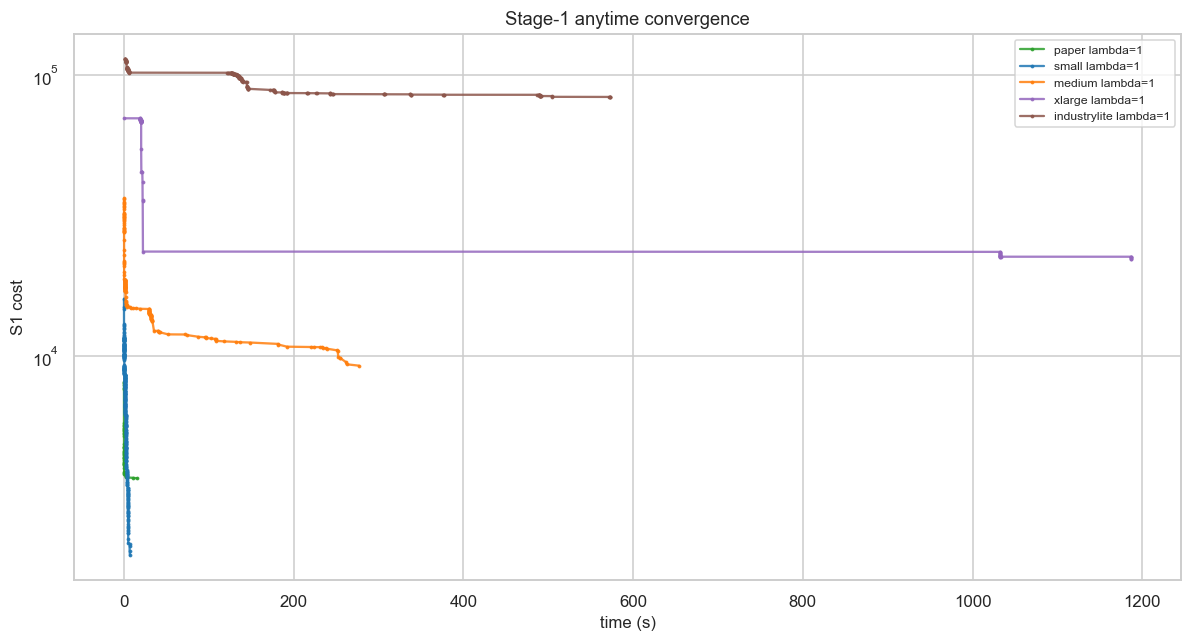

In [92]:
def plot_s1_trajectory(df):
    fig, ax = plt.subplots(figsize=(11, 6))
    for size in present_sizes:
        s = df[df["instance_size"] == size].drop_duplicates(["instance_name", "lambda_rel"])
        # mid-range lambda where Stage 1 is hardest
        cand = s[s["lambda_rel"] == 1.0]
        row = (cand.iloc[0] if not cand.empty else s.iloc[0])
        try:
            traj = json.loads(row["s1_trajectory"])
        except Exception:
            continue
        if not traj:
            continue
        t = [p["time"] for p in traj]
        c = [p["cost"] for p in traj]
        ax.plot(t, c, marker=".", markersize=3, alpha=0.85,
                color=SIZE_COLOR.get(row["instance_size"], "gray"),
                label=f"{row['instance_size']} lambda={row['lambda_rel']:g}")
    ax.set_xlabel("time (s)"); ax.set_ylabel("S1 cost")
    ax.set_yscale("log")
    ax.set_title("Stage-1 anytime convergence")
    ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

plot_s1_trajectory(df)


### 5.5 Stage-2 anytime convergence (baseline packing, one instance per size)

Same idea as 5.4 but for Stage 2 under the `baseline` config, whose
objective is a single level (number of used trips). Baseline packing is
easy on a fixed routing, so these curves converge in well under a second
even on xlarge — a contrast to the Stage-1 curves above.

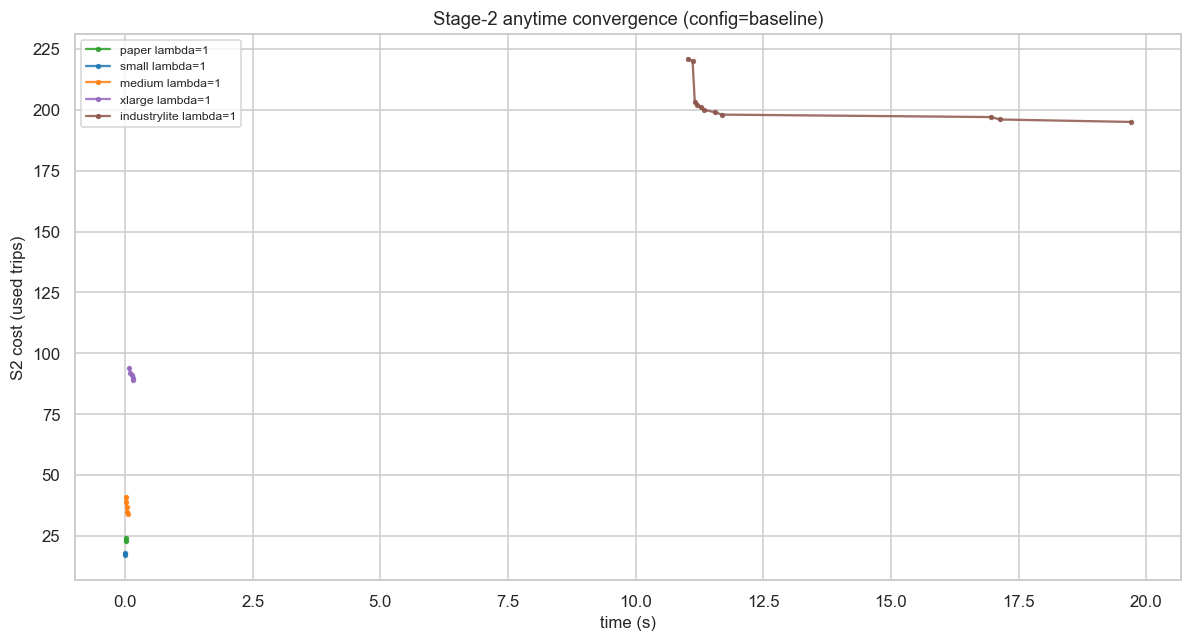

In [93]:
def plot_s2_trajectory(df, config="baseline"):
    fig, ax = plt.subplots(figsize=(11, 6))
    sub = df[df["s2_config"] == config]
    for size in present_sizes:
        s = sub[sub["instance_size"] == size].drop_duplicates(["instance_name", "lambda_rel"])
        cand = s[s["lambda_rel"] == 1.0]
        row = cand.iloc[0] if not cand.empty else (s.iloc[0] if not s.empty else None)
        if row is None:
            continue
        try:
            traj = json.loads(row["s2_trajectory"])
        except Exception:
            continue
        if not traj:
            continue
        t = [p["time"] for p in traj]
        c = [p["cost"][0] if isinstance(p["cost"], list) else p["cost"] for p in traj]
        ax.plot(t, c, marker=".", markersize=5, alpha=0.85,
                color=SIZE_COLOR.get(size, "gray"),
                label=f"{size} lambda={row['lambda_rel']:g}")
    ax.set_xlabel("time (s)"); ax.set_ylabel("S2 cost (used trips)")
    ax.set_title(f"Stage-2 anytime convergence (config={config})")
    ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

plot_s2_trajectory(df, "baseline")


---
## Summary table

Mean headline metrics grouped by (size, lambda, config). Spot-checks the
plots and pastes into prose.

In [94]:
summary = (df.groupby(["instance_size", "lambda_rel", "s2_config"], observed=True)
             .agg(r_tr=("r_tr", "mean"),
                  r_1=("r_1", "mean"),
                  k_1=("k_1", "mean"),
                  exposure=("exposure_count", "mean"),
                  mono=("mono_count", "mean"),
                  conc=("concentrated_count", "mean"),
                  s1_cost=("s1_dispatch_cost", "mean"),
                  s2_cost=("s2_dispatch_cost", "mean"),
                  save_pct=("cost_saving_pct", "mean"),
                  premium_pct=("s1_cost_premium_pct", "mean"),
                  s1_time=("s1_time", "mean"),
                  s2_time=("s2_time", "mean"),
                  s1_opt=("s1_optimal", "mean"),
                  s2_opt=("s2_optimal", "mean"),
                  n=("r_tr", "size"))
             .round(3))
summary


r_tr    r_1    k_1  exposure   mono  \
instance_size lambda_rel s2_config                                         
paper         0.0        baseline   0.500  0.800  0.800       5.0   3.00   
                         mixed      0.500  0.850  0.850       5.0   2.00   
                         even       0.500  0.800  0.800       5.0   6.00   
                         full       0.500  0.800  0.800       5.0   5.00   
              0.1        baseline   0.500  0.750  0.750       3.0   7.00   
...                                   ...    ...    ...       ...    ...   
industrylite  1.0        full       0.617  0.817  0.817      10.5  52.75   
              4.0        baseline   0.633  0.775  0.775       8.0  37.25   
                         mixed      0.633  0.808  0.808       8.0   6.00   
                         even       0.633  0.767  0.767       8.0  76.25   
                         full       0.633  0.767  0.767       8.0  52.25   

                                      conc   s1_cost   s2_cost  save_pct  \
instance_size lambda_rel s2_config                                         
paper         0.0        baseline    23.00   3458.00   2744.00    20.648   
                         mixed       18.00   3458.00   2744.00    20.648   
                         even        10.00   3458.00   3458.00     0.000   
                         full        10.00   3458.00   3458.00     0.000   
              0.1        baseline    19.00   3458.00   2688.00    22.267   
...                                    ...       ...       ...       ...   
industrylite  1.0        full       260.00  71099.75  62015.25    12.625   
              4.0        baseline   341.25  75598.25  56969.00    23.853   
                         mixed      353.50  75598.25  57404.50    23.407   
                         even       235.75  75598.25  66933.75    10.742   
                         full       247.25  75598.25  65748.25    11.381   

                                    premium_pct  s1_time  s2_time  s1_opt  \
instance_size lambda_rel s2_config                                          
paper         0.0        baseline         0.000   10.654    0.028     1.0   
                         mixed            0.000   10.654    0.031     1.0   
                         even             0.000   10.654    0.026     1.0   
                         full             0.000   10.654    0.028     1.0   
              0.1        baseline         0.000   18.603    0.023     1.0   
...                                         ...      ...      ...     ...   
industrylite  1.0        full            24.730  608.817  414.001     0.0   
              4.0        baseline        29.623  602.920  453.654     0.0   
                         mixed           29.623  602.920  454.626     0.0   
                         even            29.623  602.920  153.818     0.0   
                         full            29.623  602.920  201.636     0.0   

                                    s2_opt  n  
instance_size lambda_rel s2_config             
paper         0.0        baseline     1.00  1  
                         mixed        1.00  1  
                         even         1.00  1  
                         full         1.00  1  
              0.1        baseline     1.00  1  
...                                    ... ..  
industrylite  1.0        full         0.50  4  
              4.0        baseline     0.25  4  
                         mixed        0.25  4  
                         even         0.75  4  
                         full         0.75  4  

[144 rows x 15 columns]